# Session 1 - Regression Task: predicting continuous values

This part will be delivered on blackboard, until hands-on practice.

## Classification versus Regression

Following the lecture on Wednesday, both classification and regression are ***model-fitting problem***, but with different purpose and different target.

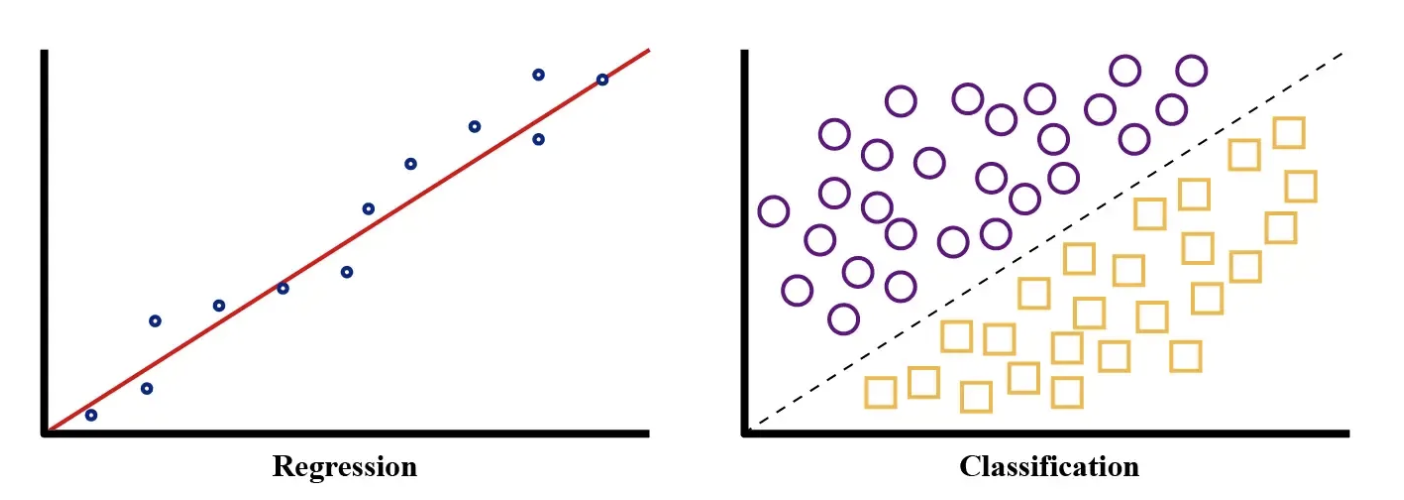

- Classification → predict a category: fit a model for decision boundary that separates different classes. For binary classification: $$ P(y=1~|~\mathbf{x}) = g (f(\mathbf{x})) \in (0,1),$$ where $f(x)$ generally denotes for the decision function and $g(z)$ maps the acquired values into a probability distribution.
- Regression → literally a fitting problem, predicting a ***continuous numerical value***: fit a model that describes the relationship between between a dependent variable (target) and one or multiple input features: $$ \hat{y} = f(\mathbf{x}). $$





## Linear Regression

### Simplified case: one input feature

Given a set of samples $\Omega = \{(x_i, y_i)\}_{i=1}^{n}$, where $x$ denotes an input feature and $y$ is the corresponding target value. The linear model is described as: 

$$
\hat{y_i} = f(\mathbf{x}) = \beta_0 + \beta_1 x_i.
$$

The residual for each data point is 
$$
e_i = y_i - \hat{y}_i.
$$

<div align="center">
    <img src="linear_regression.png" width="600">
</div>

#### Least-sqaures fitting

To decide which combination of $\beta$ is the best, we need a **measure of fit (goodness of fit)**. The simplest and standard choice is ***least-square fitting***, i.e. summing up the residuals between the model and the target value. The total squared residual is calculated as follows:

$$ 
\mathrm{SSE} = \sum_{i=1}^{N}(y_i-\hat y_i)^2 = \sum_{i=1}^{N}(y_i-\beta_0-\beta_1x_i)^2
$$

The linear regression chooses the optimal $\beta_0$ and $\beta_1$ by minimising the total squared residual. This fitting process can then be written as 

$$
(\hat\beta_0,\hat\beta_1)=\arg\min_{\beta_0,\beta_1}\sum_i(y_i-\beta_0-\beta_1x_i)^2
$$

For such a simple linear relation, there is analytical solution: 

$$
\boxed{\hat\beta_1=\frac{\sum_i(x_i-\bar x)(y_i-\bar y)}{\sum_i(x_i-\bar x)^2},
\qquad \hat\beta_0=\bar y-\hat\beta_1\bar x}
$$


### Generalised linear regression model

Given a set of samples $\Omega = \{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$, where $\mathbf{x}_i = (x_{i1}, x_{i2}, \dots, x_{ip})^\top \in \mathbb{R}^p$ denotes a set of $p$ input features of the $i$-th sample and $y_i \in \mathbb{R}$ denotes its corresponding target value, a linear model is described as:

$$
f(\mathbf{x}) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p = \boldsymbol{\beta}^\top \tilde{\mathbf{x}}
$$

where $\boldsymbol{\beta} = (\beta_0, \beta_1, \dots, \beta_p)^\top \in \mathbb{R}^{p+1}$ is the parameter vector and $\tilde{\mathbf{x}} = (1, x_1, \dots, x_p)^\top$ is the feature vector augmented with a constant 1 to absorb the intercept $\beta_0$.

#### Dataset Matrix

$$
X = \begin{pmatrix} 1 & x_{11} & \cdots & x_{1p} \\ 1 & x_{21} & \cdots & x_{2p} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_{n1} & \cdots & x_{np} \end{pmatrix} \in \mathbb{R}^{n \times (p+1)}, 
\qquad \boldsymbol{\beta}=\begin{pmatrix}\beta_0\\\beta_1\\\vdots\\\beta_p\end{pmatrix}., 
\qquad \mathbf{y} = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{pmatrix} \in \mathbb{R}^{n}
$$

The model for the whole dataset is then described as:

$$
\mathbf{y} = X\boldsymbol{\beta}
$$

A unique solution requires at least $p + 1$ distinct $x_i$ values, i.e. the number of data $n \geq (p+1)$.

#### Least-squares Fitting

To estimate the optimal $\boldsymbol{\beta}$ by minimising the total squared residual, the equation is written as: 

$$
\hat{\boldsymbol{\beta}} = \arg\min_{\boldsymbol{\beta}} \lVert \mathbf{y} - X\boldsymbol{\beta} \rVert_2^2
$$

When the $X^TX$ is invertible, there is an analytical solution: 
$$
\boxed{\hat{\boldsymbol{\beta}}=(X^TX)^{-1}X^T\mathbf y}
$$

#### Statistical View 

We can connected back to the first-day lecture and view this from statistical perspective. 

Let's say the residual arises from measurement errors in the observation space. Given the assumption that these errors are indpendent, Gaussian, and centred around zero, this quantifies *how likely each observed data point is for a given model*. 

Assume each observation is generated as

$$
y_i = \mathbf{x}_i^\top \boldsymbol{\beta} + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2), \text{ independent}
$$

The probability of a $y_i$ given $\boldsymbol{\beta}$ in Gaussian form: 

$$
p(y_i \mid \boldsymbol{\beta}) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left( -\frac{(y_i - \mathbf{x}_i^\top \boldsymbol{\beta})^2}{2\sigma^2} \right)
$$

The likelihood of a particular model $\boldsymbol{\beta}$ is the probability of observing ***all the data points***, given that model.
$$
L(\boldsymbol{\beta}) = \prod_{i=1}^{n} p(y_i \mid \boldsymbol{\beta}) = p(y_1,y_2,\ldots,y_n\mid\boldsymbol{\beta})
=p(y_1\mid\boldsymbol{\beta})p(y_2\mid\boldsymbol{\beta})\cdots p(y_n\mid\boldsymbol{\beta}).
$$

To maximise the likelihood $L(\boldsymbol{\beta})$, one can choose to minimise the ***negative log*** of the likelihood: 

$$\hat{\boldsymbol{\beta}}=\arg\max_{\boldsymbol{\beta}}L(\boldsymbol{\beta})=\arg\min_{\boldsymbol{\beta}}
[-\log L(\boldsymbol{\beta})].$$

The negative log of the likelihood is as follows: 

$$
-\log L(\boldsymbol{\beta}) = \frac{n}{2}\log(2\pi\sigma^2) + \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - \mathbf{x}_i^\top \boldsymbol{\beta})^2,
$$

where the first term does not depend on $\boldsymbol{\beta}$, and $1/(2\sigma^2)$ is just a positive constant. Thus, the key item to be minimised is 

$$
\sum_{i=1}^{n} (y_i - \mathbf{x}_i^\top \boldsymbol{\beta})^2 = \lVert \mathbf{y} - X\boldsymbol{\beta} \rVert_2^2.
$$

This is exactly the least-squares criterion. Thus, under these assumptions, the maximum-likelihood estimate and the least-squares estimate resulted in the same $\hat{\boldsymbol{\beta}}$.


## Optimisation with Gradient Descent

The analytical solution requires $X^TX$ being invertible, which has a basic assumption that each feature in the matrix, $X$, is independent. In astronomical case, this is often not the case $-$ the variables we use as predictors are commonly correlated with each other. In such case, we can approach the optimal $\boldsymbol{\beta}$ numerically in least-squares fitting with gradient descent. 

Starting with the loss function, which is the summation of the least squares: 
$$
\hat{\boldsymbol{\beta}} = \arg\min_{\boldsymbol{\beta}} \lVert \mathbf{y} - X\boldsymbol{\beta} \rVert_2^2
$$
$$
\lVert \mathbf{y} - X\boldsymbol{\beta} \rVert_2^2 = \sum_{i=1}^{n} (y_i - \mathbf{x}_i^\top \boldsymbol{\beta})^2.
$$

The derivative of a linear regression model can be written analytically: 

$$
\nabla_{\boldsymbol\beta} \sum_{i=1}^n (y_i - \mathbf{x}_i^\top\boldsymbol\beta)^2 = -2\sum_{i=1}^n \mathbf{x}_i\,(y_i - \mathbf{x}_i^\top\boldsymbol\beta).
$$

This is the form stochastic gradient descent (SDG) uses: each term $-2\mathbf{x}_i(y_i - \mathbf{x}_i^\top\boldsymbol\beta)$ is the gradient from a single data point, and SGD updates using one term (or a minibatch) at a time. The summation grows as the number of data increases, making it difficult to choose the right scale of learning rates. Thus, the common practice the term is divided by the number of data, i.e. convert into **mean-squared error (MSE)**:

$$
\nabla_{\boldsymbol\beta} L = -\frac{2}{n}\sum_{i=1}^n \mathbf{x}_i\,(y_i - \mathbf{x}_i^\top\boldsymbol\beta) = -\frac{2}{n} X^T (\mathbf{y} - X\boldsymbol{\beta})
$$

Update the weights with 
$$
\boxed{\boldsymbol\beta \leftarrow \boldsymbol\beta - \eta\nabla_{\boldsymbol\beta} L = \boldsymbol\beta + \frac{2\eta}{n}X^\top(\mathbf{y} - X\boldsymbol\beta)},
$$
where $\eta$ denotes **learning rates**. 

## Polynomial Regression

To simplify the demonstration, let's use the case of one input feature, $x_i$, with a polynomial of degree $p$. 

Given a set of samples $\Omega = \{(x_i, y_i)\}_{i=1}^{n}$, where $x$ denotes an input feature and $y$ is the corresponding target value. The polynomial model of degree $p$ is described as: 
$$
y_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \dots + \beta_p x_i^p
$$

Polynomial regression is a linear least squares problem, as while the model is nonlinear in feature space $x$, it is **linear in the parameters** $\boldsymbol{\beta} = (\beta_0, \dots, \beta_p)^T$.

#### Dataset Matrix

Each row of $X$ contains the powers of one $x_i$. This is the Vandermonde matrix:

$$
X =
\begin{pmatrix}
1 & x_1 & x_1^2 & \cdots & x_1^p \\
1 & x_2 & x_2^2 & \cdots & x_2^p \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_n & x_n^2 & \cdots & x_n^p
\end{pmatrix}
\in \mathbb{R}^{n \times (p+1)}
$$

The model remains $\mathbf{y} = X\boldsymbol{\beta}$, same as the linear regression model but with a specific design matrix. A unique solution requires at least $p + 1$ distinct $x_i$ values, i.e. the number of data $n \geq (p+1)$.

#### Least-squares Fitting

To estimate the optimal $\boldsymbol{\beta}$ by minimising the total squared residual:

$$
\hat{\boldsymbol{\beta}} = \arg\min_{\boldsymbol{\beta}} \lVert \mathbf{y} - X\boldsymbol{\beta} \rVert_2^2
$$

Setting the gradient to zero, $-2X^T(\mathbf{y} - X\boldsymbol{\beta}) = \mathbf{0}$, gives the normal equations $X^TX\boldsymbol{\beta} = X^T\mathbf{y}$. When $X^TX$ is invertible:

$$
\boxed{\hat{\boldsymbol{\beta}} = (X^TX)^{-1}X^T\mathbf{y}}
$$

## Hands-on: Build a linear regression model (Example Code)

In this exercise, you goal is to build a linear regressor for predicting the stellar mass of galaxies with three different approaches: 

1. analytical solution
2. optimisation process
3. scikit-learn: linear and polynomial regression fitting

In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

In [2]:
#### Helper function ####

def evaluate(y_true, y_pred):
    """Quick metric for evaluting the performance of the regression models"""
    resid = y_true - y_pred                                                 # calculate residual
    mse = np.mean(resid ** 2)                                               # mean-squared error; rmse: root-mean-squared error
    r2 = 1 - np.sum(resid ** 2) / np.sum((y_true - y_true.mean()) ** 2)     # r2    
    return mse, np.sqrt(mse), r2

def result_plot(y_true, y_pred):
    """Quick plot for evaluating the performance of the regression models

    Example: 
        result_plot(y_true, y_pred)
    """
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
    ax[0].hexbin(y_true, y_pred, gridsize=80, bins="log", cmap="viridis")
    lims = [y_true.min(), y_true.max()]
    ax[0].plot(lims, lims, "r--", lw=1)
    ax[1].hist(y_true - y_pred, bins=100, color="steelblue")
    ax[1].set(xlabel="residual (true - predicted)", ylabel="count", title="Residuals")
    plt.tight_layout()

In [3]:
#### Read Data ####

df = pd.read_csv('known_datasets.csv')

In [4]:
#### Spilt training and testing data (80:20) ####

n_train = int(0.8 * len(df))

train_idx = np.random.choice(df.index, n_train, replace=False)                # Selecting data for training (constructing regression models)      
test_idx = np.delete(df.index, train_idx)                                     # The rest of data do not appear in the training process

y_train, y_test = df['logM'][train_idx].values, df['logM'][test_idx].values   # Target value: stellar mass

In [5]:
#### Constructing the input feature X #### 

def design_matrix(features, rows_idx):
    """Columns of the chosen features with a leading column of ones.

    Example: 
        features = ['gmag', 'rmag']  
        X_train = design_matrix(features, train_idx)

    Output: 
        array([[1.  , 0.5 , 0.85],
               [1.  , 6.45, 0.24],
               [1.  , 4.14, 0.82],
               ...,
               [1.  , 4.27, 0.21],
               [1.  , 6.36, 0.34],
               [1.  , 4.2 , 0.24]], shape=(184277, 3))
    """
    X = np.column_stack([df[n][rows_idx].values for n in features])
    return np.column_stack([np.ones(len(rows_idx)), X])

### Analytical Solution

This is the only function you need to find the optimal $\boldsymbol{\beta}$ in this part of the exercise.
$$
\boxed{\hat{\boldsymbol{\beta}} = (X^TX)^{-1}X^T\mathbf{y}}
$$

features: rMag + g-r     beta: [0.6991, -0.4250, 1.3663]          mse: 0.0089   rmse: 0.0946   r2: 0.9777


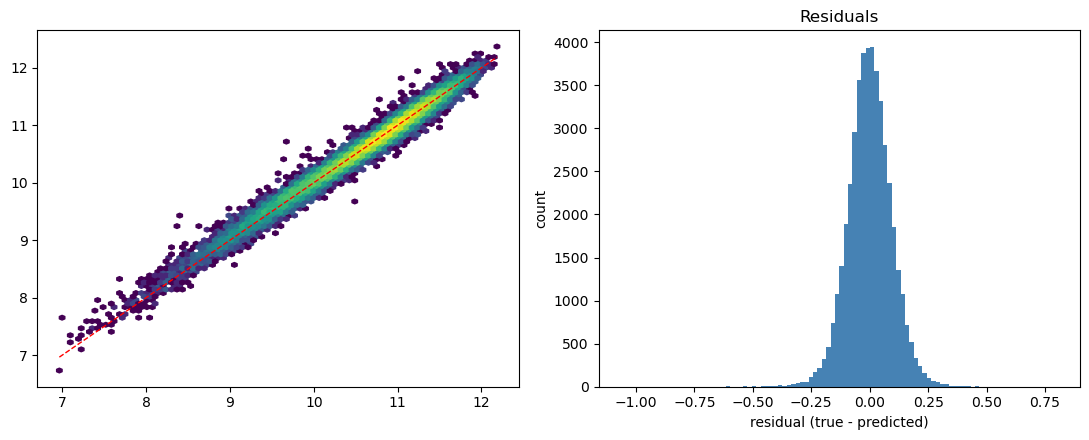

In [6]:
def fit(X, y):
    """Analytical solution: w = (X^T X)^{-1} X^T y."""
    beta = np.linalg.inv(X.T @ X) @ X.T @ y
    return beta

features = ['rMag', 'g-r']                          # Choose any features (any number) that you consider useful for predicting stellar mass
X_train = design_matrix(features, train_idx)        # Construct the input features matrix X

beta = fit(X_train, y_train)                        # Use the analytical solution to find beta

y_pred = design_matrix(features, test_idx) @ beta   # Use the derived beta for unseen data
mse, rmse, r2 = evaluate(y_test, y_pred)            # Evaluation
label = " + ".join(features)
coef = "[" + ", ".join(f"{c:.4f}" for c in beta) + "]"
print(f"features: {label:<14} beta: {coef:<34} mse: {mse:.4f}   rmse: {rmse:.4f}   r2: {r2:.4f}")

result_plot(y_test, y_pred)

### Optimisation Process: Gradient Descent

In this exercise, you will code to use gradient descent to derive the optimal $\boldsymbol{\beta}$ after a few iterations.

The derivative of the loss function is
$$
\nabla_{\boldsymbol\beta} L = -\frac{2}{n}\sum_{i=1}^n \mathbf{x}_i\,(y_i - \mathbf{x}_i^\top\boldsymbol\beta) = -\frac{2}{n} X^T (\mathbf{y} - X\boldsymbol{\beta}).
$$

The analytical form of the gradient descent update:

$$
\boxed{\boldsymbol\beta \leftarrow \boldsymbol\beta - \eta\nabla_{\boldsymbol\beta} L = \boldsymbol\beta + \frac{2\eta}{n}X^\top(\mathbf{y} - X\boldsymbol\beta)}
$$

features: rMag + g-r     beta: [0.0231, -0.4969, 0.0153]          mse: 0.0386   rmse: 0.1964   r2: 0.9040


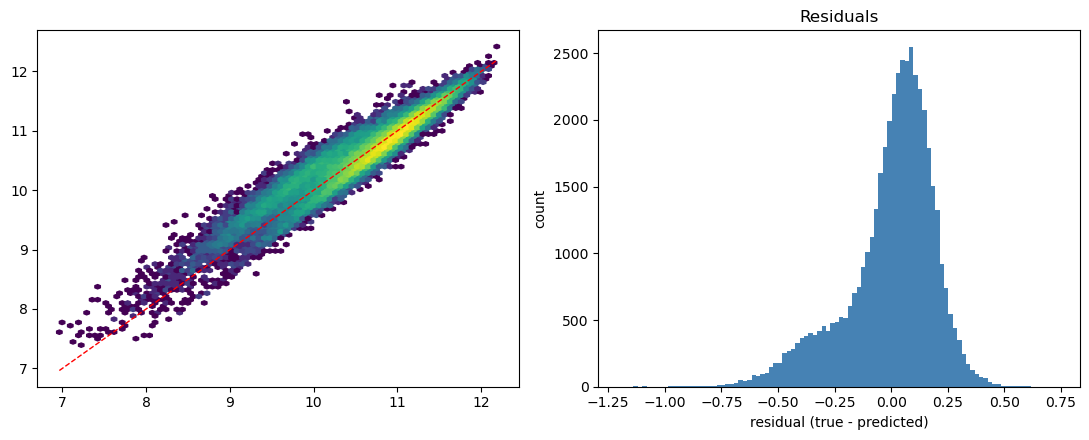

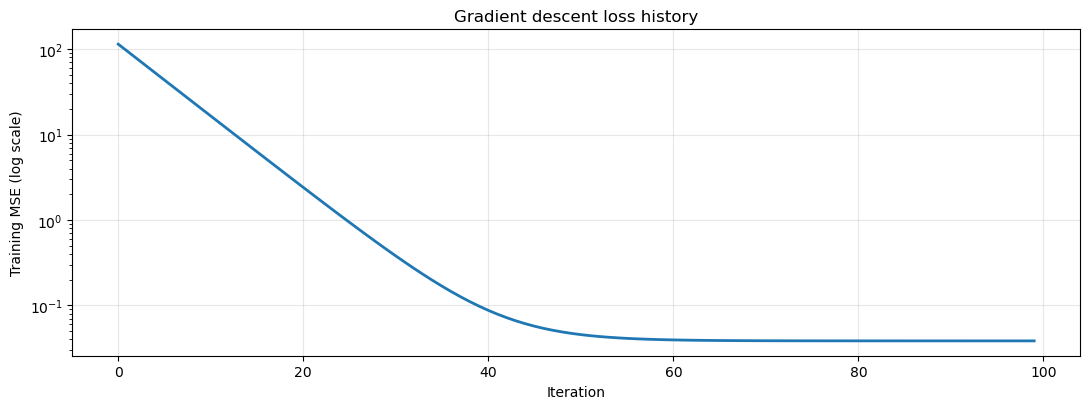

In [7]:
def fit(X, y, lr=0.0001, n_iters=100, tol=1e-10):
    """Update the beta with a number of iterations"""
    n, d = X.shape
    beta = np.zeros(d)                    # Initial condition: beta = 0

    history = []
    for k in range(n_iters):
        residual = y - X @ beta
        grad = -(2 / n) * X.T @ residual  # Gradient term
        beta = beta - lr * grad           # Update the beta
        history.append(residual @ residual / n)
        
        if np.linalg.norm(grad) < tol:    # If the loss is sufficiently low, satisfying the set tolerance
            break
            
    return beta, history

def train_history(history):
    fig, axes = plt.subplots(1, 1, figsize=(11, 4.2))
 
    axes.plot(history, lw=2)
    axes.set_yscale("log")
    axes.set_xlabel("Iteration")
    axes.set_ylabel("Training MSE (log scale)")
    axes.set_title("Gradient descent loss history")
    axes.grid(alpha=0.3)

    plt.tight_layout()

features = ['rMag', 'g-r']                          # Choose any features (any number) that you consider useful for predicting stellar mass
X_train = design_matrix(features, train_idx)        # Construct the input features matrix X

beta, history = fit(X_train, y_train)               # Use gradient descent to find optimal beta

y_pred = design_matrix(features, test_idx) @ beta   # Use the derived beta for unseen data
mse, rmse, r2 = evaluate(y_test, y_pred)            # Evaluation
label = " + ".join(features)
coef = "[" + ", ".join(f"{c:.4f}" for c in beta) + "]"
print(f"features: {label:<14} beta: {coef:<34} mse: {mse:.4f}   rmse: {rmse:.4f}   r2: {r2:.4f}")

result_plot(y_test, y_pred)
train_history(history)

### Scikit-learn package

Check the website for instruction: [sklearn.linear_model.LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

features: rMag + g-r     beta: [0.0000, -0.4250, 1.3663]          mse: 0.0089   rmse: 0.0946   r2: 0.9777


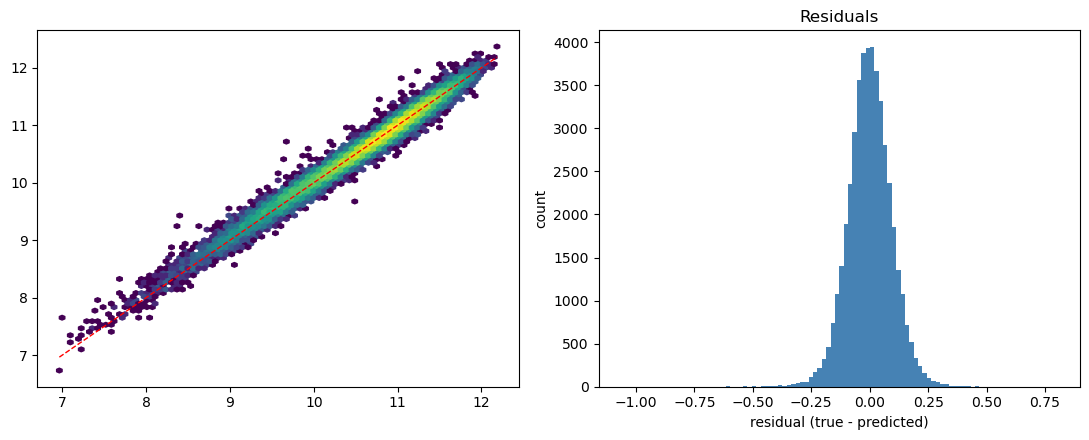

In [8]:
def fit(X, y):
    reg = sklearn.linear_model.LinearRegression()
    return reg.fit(X, y)

features = ['rMag', 'g-r']                          # Choose any features (any number) that you consider useful for predicting stellar mass
X_train = design_matrix(features, train_idx)        # Construct the input features matrix X

linear_reg = fit(X_train, y_train)                  # Use scikit-learn package
beta = linear_reg.coef_
y_pred = linear_reg.predict(design_matrix(features, test_idx))

mse, rmse, r2 = evaluate(y_test, y_pred)            # Evaluation
label = " + ".join(features)
coef = "[" + ", ".join(f"{c:.4f}" for c in beta) + "]"
print(f"features: {label:<14} beta: {coef:<34} mse: {mse:.4f}   rmse: {rmse:.4f}   r2: {r2:.4f}")

result_plot(y_test, y_pred)


### Predict new datasets: tabular

The catalogue `new_datasets.csv` contains 5 galaxies without stellar mass measurement. The properties provided is the same as the previous catalogue `known_datasets.csv`. Build a linear regression model of your own choice, and record your answer for each galaxy on this [**Google Doc**](https://docs.google.com/document/d/1Wcu2wqmJlopgx4V42Fe1ZqupgcFVDA0xlR90FwoM_q4/edit?usp=sharing).

In [9]:
#### Prediction from participants ####

preds4new = {'answers': [9.769, 8.095, 8.883, 11.238, 10.332], 
             'Antonio_scikit' : [10.902, 10.940, 11.825, 10.658, 11.176],
             'GD' : [10.744, 10.728, 11.770, 10.911, 11.206],
             'Haifan' : [9.8097,8.114,8.948,11.276,10.269], 
             'Gabriel' : [9.85,9.57,9.58,11.05,10.37], 
             'Will_gd' : [10.168, 8.288, 9.278, 11.161, 10.345], 
             'Will_sk' : [9.110, 7.372, 8.236, 10.589, 9.589],
             'Marthe': [9.69358814,  8.08903994,  8.87106361, 11.41228473,  9.97959571],
             'Jiang': [9.84, 8.01, 8.98, 10.93, 10.00],
             'Daniel': [ 9.80445773,  8.21700126,  8.99702679, 11.27308905, 10.30606493], 
             'Yfke': [9.115, 7.375, 8.240, 10.594, 9.593]
}

=== Per-galaxy distribution ===
            true    mean  median    std     min     max    sem  mean - true
Galaxy 0   9.769   9.904   9.825  0.586   9.110  10.902  0.185        0.135
Galaxy 1   8.095   8.670   8.166  1.291   7.372  10.940  0.408        0.575
Galaxy 2   8.883   9.473   8.989  1.292   8.236  11.825  0.408        0.590
Galaxy 3  11.238  10.985  10.990  0.300  10.589  11.412  0.095       -0.253
Galaxy 4  10.332  10.283  10.288  0.557   9.589  11.206  0.176       -0.049 

=== Crowd average ===
RMSE of crowd mean  : 0.391 dex
Mean bias (pred-true): +0.200 dex

=== Leaderboard (ranked by RMSE) ===
                rank   RMSE    MAE   bias  max_abs_err
Haifan             1  0.048  0.045  0.020        0.065
Daniel             2  0.079  0.067  0.056        0.122
Marthe             3  0.179  0.124 -0.054        0.352
Jiang              4  0.213  0.179 -0.111        0.332
Will_gd            5  0.268  0.215  0.185        0.399
Yfke               6  0.681  0.680 -0.680        0.739

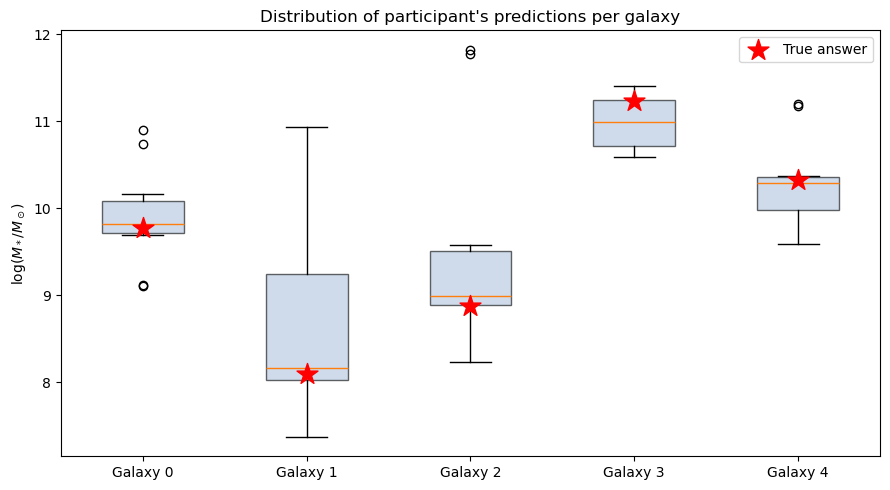

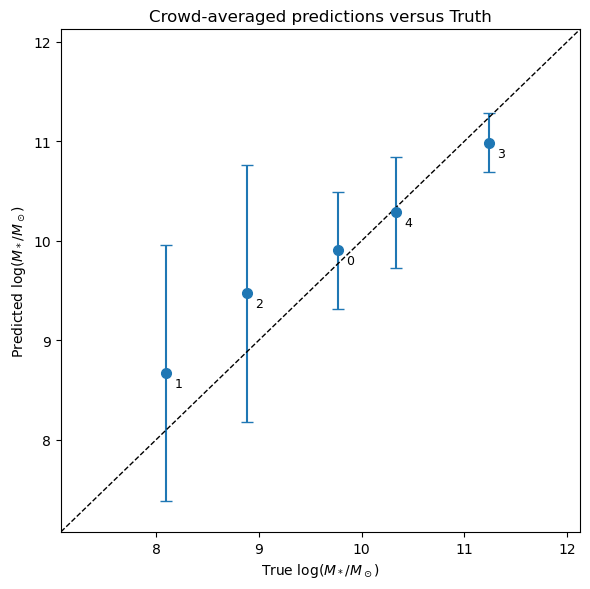

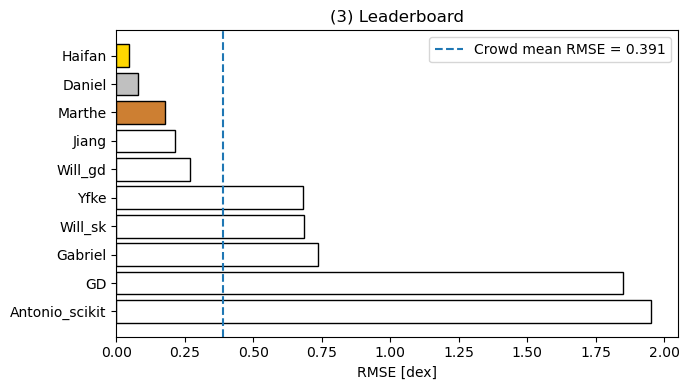

In [10]:
#### Evaluation and Leaderboard ####

df = pd.DataFrame(preds4new)
df.index = [f'Galaxy {i}' for i in range(len(df))]

truth = df.pop('answers')
participants = df.columns.tolist()
galaxies = df.index.tolist()
x = np.arange(len(galaxies))

######################################### 
# 1. Prediction distribution per galaxy #
#########################################
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([df.loc[g].values for g in galaxies], positions=x, widths=0.5,
           patch_artist=True, boxprops=dict(facecolor='lightsteelblue', alpha=0.6))

ax.scatter(x, truth.values, marker='*', s=250, color='red', zorder=4, label='True answer')
ax.set_xticks(x)
ax.set_xticklabels(galaxies)
ax.set_ylabel(r'$\log(M_*/M_\odot)$')
ax.set_title('Distribution of participant\'s predictions per galaxy')
ax.legend()
plt.tight_layout()

print('=== Per-galaxy distribution ===')
summary = pd.DataFrame({
    'true': truth,
    'mean': df.mean(axis=1),
    'median': df.median(axis=1),
    'std': df.std(axis=1, ddof=1),
    'min': df.min(axis=1),
    'max': df.max(axis=1),
})
summary['sem'] = summary['std'] / np.sqrt(len(participants))
summary['mean - true'] = summary['mean'] - summary['true']
print(summary.round(3), '\n')


########################################
# 2. Pred versus True: One-to-one plot #
########################################
fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(truth, summary['mean'], yerr=summary['std'], fmt='o', color='C0',
            ecolor='C0', capsize=4, ms=7)
lo = min(truth.min(), df.values.min()) - 0.3
hi = max(truth.max(), df.values.max()) + 0.3
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
for g, t, m in zip(galaxies, truth, summary['mean']):
    ax.annotate(g.split()[-1], (t, m), xytext=(6, -10), textcoords='offset points', fontsize=9)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel(r'True $\log(M_*/M_\odot)$')
ax.set_ylabel(r'Predicted $\log(M_*/M_\odot)$')
ax.set_title('Crowd-averaged predictions versus Truth')
plt.tight_layout()

crowd_rmse = np.sqrt(np.mean((summary['mean'] - truth) ** 2))
print('=== Crowd average ===')
print(f'RMSE of crowd mean  : {crowd_rmse:.3f} dex')
print(f'Mean bias (pred-true): {summary["mean - true"].mean():+.3f} dex\n')


##################
# 3. Leaderboard #
##################
resid = df.sub(truth, axis=0)
scores = pd.DataFrame({
    'RMSE': np.sqrt((resid ** 2).mean()),
    'MAE': resid.abs().mean(),
    'bias': resid.mean(),
    'max_abs_err': resid.abs().max(),
}).sort_values(['RMSE', 'MAE'])                           # rank by RMSE, MAE breaks ties
scores.insert(0, 'rank', range(1, len(scores) + 1))

print('=== Leaderboard (ranked by RMSE) ===')
print(scores.round(3), '\n')
medals = ['🥇', '🥈', '🥉']
for medal, (name, row) in zip(medals, scores.head(3).iterrows()):
    print(f'{medal} {name}: RMSE = {row.RMSE:.3f} dex, MAE = {row.MAE:.3f} dex')

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['gold', 'silver', '#cd7f32'] + ['white'] * (len(scores) - 3)
ax.barh(scores.index[::-1], scores['RMSE'][::-1], color=colors[::-1], edgecolor='k')
ax.axvline(crowd_rmse, color='C0', ls='--', label=f'Crowd mean RMSE = {crowd_rmse:.3f}')
ax.set_xlabel('RMSE [dex]')
ax.set_title('(3) Leaderboard')
ax.legend()
plt.tight_layout()

# Session 2 - Regularisation and Model Selection

## Underfitting and Overfitting

- Underfitting: the model is not sufficiently complex to capture the underlying patterns or complexity present in the dataset.
- Overfitting: the model is overly complex relative to the information actually contained in the dataset. This occurs when the number of features or degrees of freedom (DoF), $p$, exceeds the number of data points, $n$. In this case, the data may not provide enough constraints to determine a unique solution. 

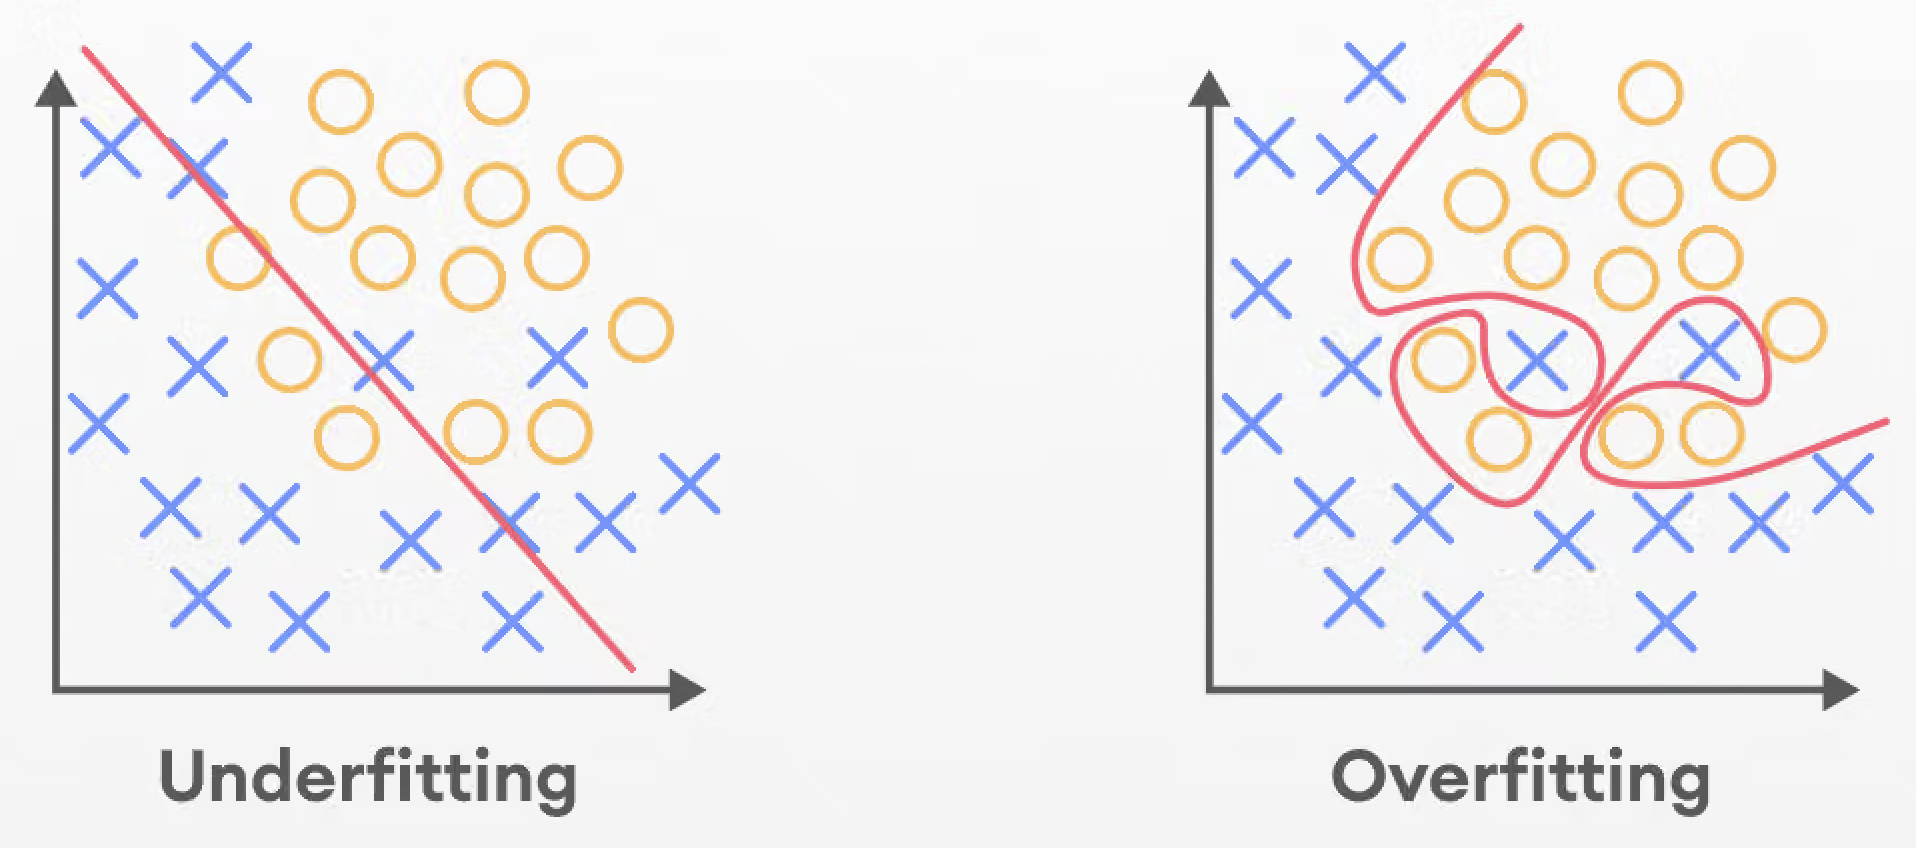

### Statistical view: Bias-Variance trade-off
From linear algebra, when $p>n$, a linear regression model generally does not have a unique least-squares solution, because there are more parameters to estimate than observations. 

This issue can also be discussed from a statistical perspective $-$ as model complexity increases, the model becomes more flexible but also more sensitive to the particular training data. This is the so-called ***Bias-Variance trade-off***. 

- ***Bias***: how far the model is from the truth. This is calculated as the difference between the expected value of an estimator and the true value of the parameter being estimated. High bias means that the model is far from the truth, likely too simple (underfitting).
- ***Variance***: how much the model changes from one training sample to another. High variance means the model is too sensitive to the training data (overfitting)

Given $\beta$ is the true parameter (a fixed number), and $\hat\beta$ is its estimator (data-driven; depends on the sample). Let $\mu = E[\hat\beta]$ be the average value of the estimator. Then

$$
Bias(\hat\beta) = \mu - \beta, \qquad
Var(\hat\beta) = E\big[(\hat\beta - \mu)^2\big]
$$

When estimating a parameter $\beta$, the error of the estimator $\hat\beta$ splits into bias and variance only.

$$
MSE(\hat\beta) = E\big[(\hat\beta - \beta)^2\big] = (\mu - \beta)^2 + E\big[(\hat\beta - \mu)^2\big] = \text{Bias}^2 + \text{Variance}
$$

### Diagnosis
| | Training error | Validation error | Remedy direction |
|---|---|---|---|
| Underfitting | High | High | More flexible model, better features, less regularisation |
| Good fit | Low | Low, close to training | — |
| Overfitting | Very low | High compared to trainin error | Regularisation, more data, simpler model |

### Remedies
- Regularisation: constraining the model
- Data augmentation: increase the sample size

## Regularisation

The key concept of regularisation is to keep the flexible model, but make complexity costly by introducing penality on large weights:

$$L(\boldsymbol{\beta}) = \text{MSE}(\boldsymbol{\beta}) + \lambda \cdot \text{Penalty}(\boldsymbol{\beta}),$$

where $\lambda$ is the dial: $\lambda = 0$ gives ordinary least squares; very large $\lambda$ pushes all weights towards zero.

### Ridge (L2)

$$\text{Penalty} = \sum_j \boldsymbol{\beta}_j^2$$

The gradient of the penalty term is $2\lambda\boldsymbol\beta$, so the gradient descent update becomes:

$$
\boldsymbol\beta \leftarrow \boldsymbol\beta - \eta\nabla_{\boldsymbol\beta} L = \boldsymbol\beta - \eta(\nabla \text{MSE} + 2\lambda \boldsymbol\beta) = (1 - 2\eta\lambda)\,{\boldsymbol\beta} - \eta \nabla \text{MSE}
$$

This affects that before each normal gradient step, the weights are multiplied by a number slightly less than 1, given both $\lambda$ and $\eta$ are positive values. Thus, L2 regularisation is called **weight decay** in neural networks.

Ridge shrinks all weights smoothly but rarely makes any of them exactly zero. This reduces the impact of a term in a fitting function, avoiding a jumpy function. 

### Lasso (L1)

$$\text{Penalty} = \sum_j |\boldsymbol\beta_j|$$

The derivative of $\lambda \sum_j |\boldsymbol\beta_j|$ is $\lambda~\text{sgn}(\boldsymbol\beta)$:

$$
\lambda \cdot \text{sgn}(\beta) = 
\begin{cases} 
  \lambda & \text{if } \beta > 0 \\ 
  -\lambda & \text{if } \beta < 0 
\end{cases}.
$$

This indicates a constant push towards zero regardless of how small the weight already is. 

### Early stopping

Early stopping regularises by keeping the parameters close to their initial values. When the initial parameters are zero or small, this acts like Ridge (L2) regularisation, keeping the model simple.

### Dropout (for neural networks)

From Wednesday's lecture, this was introduced -- it randomly deactivates some neurons which reduces the complexity of the models, reduces $p$. 

## Data augementation

Overfitting happens when the model has too much freedom relative to the data. While regularisation reduces the freedom, data augmentation aims to increase the data by creating new, realistic training examples from existing ones.

If augmenting data from the existing ones, the key principle is to **keep the labels**. However, also note that data augmentation does not increase the diversity of the datasets. 

### Examples by data type

- **Images:** flips, small rotations, crops, colour and brightness shifts
- **Time series and signals:** small noise (jitter), amplitude scaling, window shifting.
- **Tabular data:** the tricky case. Options include small Gaussian noise on continuous features. 

### Noise injection is regularisation

One interesting perspective is that, from statistical view, adding a noise term in a linear regression model is equivalent to conducting regularisation. Given inputs $x + \epsilon$, where the noise $\epsilon$ has variance $\sigma^2$, gives an expected loss of:

$$\mathbb{E}\big[(y - \beta^\top(x + \varepsilon))^2\big] = (y - \beta^\top x)^2 + \sigma^2 \lVert \beta \rVert^2$$

That's exactly the Ridge objective with $\lambda = \sigma^2$ ([Bishop, 1995](https://ieeexplore.ieee.org/document/6796505)). Augmentation and regularisation are two routes to the same goal, not separate topics.

## Hands-on Demonstration: performance with remedies

This part, we only demonstrate the results and have discussion. No coding required.

Here, we create artificial datapoints following `sin(2πx)`, with Gaussian noise. 

Three datasets:

- **train** (20 points) — small on purpose for demonstrating overfitting
- **test** (500 points) — large number so that the reported errors are stable rather than noisy

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

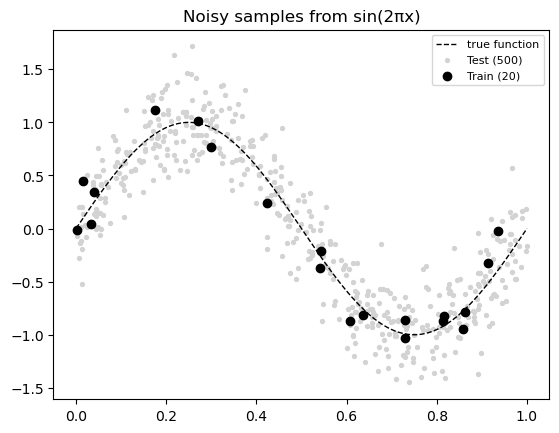

In [12]:
#### Make fake data ####

def true_f(x):
    """Data distribution: sin(2 * pi * x). Feel free to change it. """
    return np.sin(2 * np.pi * x)

def make_data(n, seed, noise=0.25):
    rng = np.random.default_rng(seed)
    x = np.sort(rng.uniform(0, 1, n))
    return x.reshape(-1, 1), true_f(x) + rng.normal(0, noise, n)

X_train, y_train = make_data(20,  seed=0)
X_test,  y_test  = make_data(500, seed=2)

#### Plot data distribution ####
X_grid = np.linspace(0, 1, 400).reshape(-1, 1)

plt.plot(X_grid, true_f(X_grid.ravel()), "k--", lw=1, label="true function")
plt.scatter(X_test, y_test, s=8, c="lightgrey", label="Test (500)")
plt.scatter(X_train, y_train, c="k", zorder=3, label="Train (20)")
plt.legend(fontsize=8); plt.title("Noisy samples from sin(2πx)"); plt.show()

### High-degree polynomial model

Fit a degree-15 polynomial model with ordinary least squares to 20 points (training data). 

In [13]:
#### Helper ####

def poly_model(estimator, degree=15):
    return make_pipeline(PolynomialFeatures(degree, include_bias=False),
                         StandardScaler(), estimator)

def report(name, predict_grid, predict_test, coefs):
    mse = mean_squared_error(y_test, predict_test)
    print(f"{name:<26} test MSE {mse:11.4f} | max|beta| {np.abs(coefs).max():12.3g}")

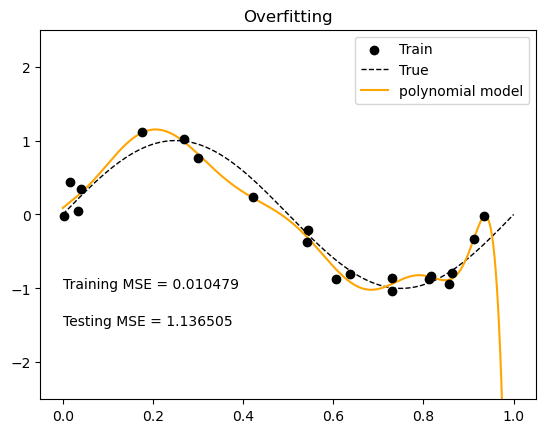

Beta: [ 1.67686315e+00 -7.52764324e+00  1.98406106e+02 -1.28745121e+03
  2.92419264e+03 -1.58653778e+03 -2.35904674e+03  9.73734975e+02
  2.73699884e+03  8.30077603e+02 -2.17439347e+03 -2.59901728e+03
  5.84471917e+02  3.69625407e+03 -1.93209774e+03]

OLS                        test MSE      1.1365 | max|beta|      3.7e+03


In [14]:
ols = poly_model(LinearRegression(), degree=15).fit(X_train, y_train)

plt.scatter(X_train, y_train, c="k", zorder=3, label="Train")
plt.plot(X_grid, true_f(X_grid.ravel()), "k--", lw=1, label="True")
plt.plot(X_grid, ols.predict(X_grid), "orange", label="polynomial model")
plt.text(0, -1, f"Training MSE = {mean_squared_error(y_train, ols.predict(X_train)):.6f}")
plt.text(0, -1.5, f"Testing MSE = {mean_squared_error(y_test, ols.predict(X_test)):.6f}")
plt.ylim(-2.5, 2.5)
plt.legend()
plt.title("Overfitting")
plt.show()

print(f"Beta: {ols[-1].coef_}\n")
report("OLS", ols.predict(X_grid), ols.predict(X_test), ols[-1].coef_)

### Overfitting: High variance 

Refit the model on five different random training samples drawn from the same true function. Overfitting models highly depend on the training dataset. The scatter of the curves indicates the variance.

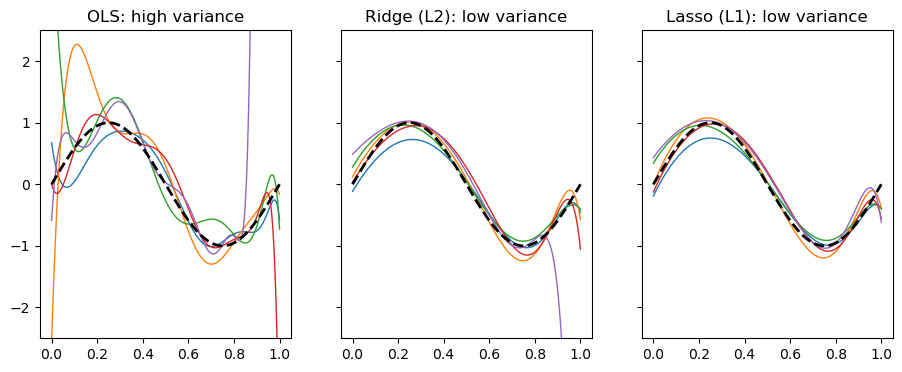

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)
for ax, (title, esti) in zip(axes, [("OLS: high variance", LinearRegression()),
                                    ("Ridge (L2): low variance", Ridge(alpha=0.01)),   # alpha -> lambda (regularisation strength)
                                    ("Lasso (L1): low variance", Lasso(alpha=0.001))]):
    for seed in range(5):
        Xs, ys = make_data(20, seed=100 + seed)
        m = poly_model(esti).fit(Xs, ys)
        ax.plot(X_grid, m.predict(X_grid), lw=1)
    ax.plot(X_grid, true_f(X_grid.ravel()), "k--", lw=2)
    ax.set_ylim(-2.5, 2.5)
    ax.set_title(title)
plt.show()

### Ridge (L2)

$$L(\boldsymbol{\beta}) = \text{MSE}(\boldsymbol{\beta}) + \lambda \cdot \sum_j \boldsymbol{\beta}_j^2$$

In [scikit-learn: Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html), $\lambda$ is called `alpha` argument. 

Ridge alpha=0              test MSE      1.1365 | max|beta|      3.7e+03
Ridge alpha=1e-06          test MSE      0.3133 | max|beta|         38.3
Ridge alpha=0.001          test MSE      0.2186 | max|beta|         5.83
Ridge alpha=0.01           test MSE      0.1027 | max|beta|         3.55
Ridge alpha=0.1            test MSE      0.1273 | max|beta|         1.37
Ridge alpha=10             test MSE      0.2724 | max|beta|        0.181


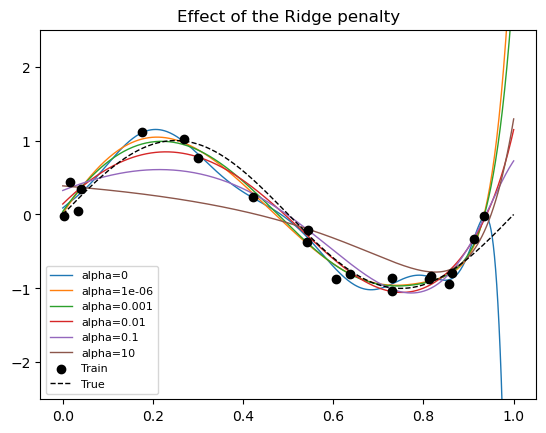

In [16]:
for a in [0.0, 1e-6, 1e-3, 1e-2, 1e-1, 10.0]:
    if a == 0:
        est = LinearRegression()
    else:
        est = Ridge(alpha=a)
    m = poly_model(est).fit(X_train, y_train)
    report(f"Ridge alpha={a:g}", m.predict(X_grid), m.predict(X_test), m[-1].coef_)
    plt.plot(X_grid, m.predict(X_grid), lw=1, label=f"alpha={a:g}")

plt.scatter(X_train, y_train, c="k", zorder=3, label="Train")
plt.plot(X_grid, true_f(X_grid.ravel()), "k--", lw=1, label="True")
plt.ylim(-2.5, 2.5); plt.legend(fontsize=8); plt.title("Effect of the Ridge penalty"); plt.show()

### Lasso (L1) 

L1 penalises the absolute value of coefficients. The penalty is a constant, keep pushing the coefficients to zero. 

In [scikit-learn: Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html), the constant $\lambda$ is called `alpha` argument. 

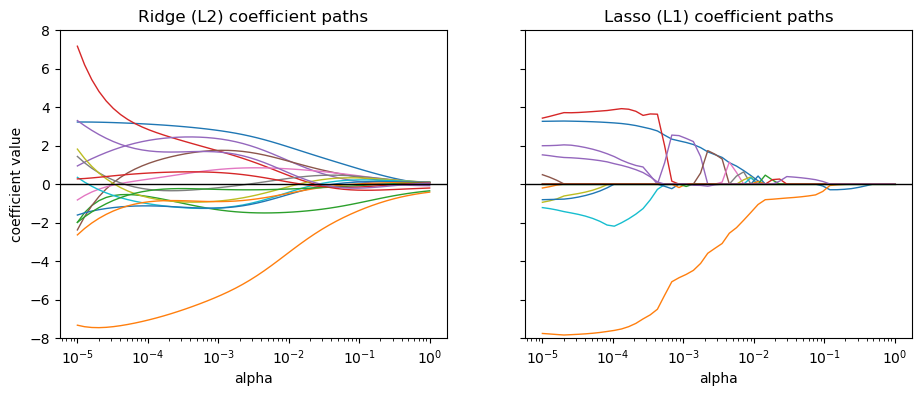

In [17]:
alphas_l = np.logspace(-5, 0, 50)
ridge_paths, lasso_paths = [], []
for a in alphas_l:
    ridge_paths.append(poly_model(Ridge(alpha=a)).fit(X_train, y_train)[-1].coef_)
    lasso_paths.append(poly_model(Lasso(alpha=a, max_iter=100000)).fit(X_train, y_train)[-1].coef_)
ridge_paths, lasso_paths = np.array(ridge_paths), np.array(lasso_paths)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, paths, name in zip(axes, [ridge_paths, lasso_paths], ["Ridge (L2)", "Lasso (L1)"]):
    ax.semilogx(alphas_l, paths, lw=1)
    ax.axhline(0, color="k", lw=1)
    ax.set_xlabel("alpha")
    ax.set_title(f"{name} coefficient paths")
axes[0].set_ylabel("coefficient value")
axes[0].set_ylim(-8, 8)
plt.show()

### Pick optimal alpha L2 and L1

Use the cross-validation (check slide from Wednesday) to select the optimal alpha for Ridge and Lasso regularisation. 
- [RidgeCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html)
- [LassoCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html)

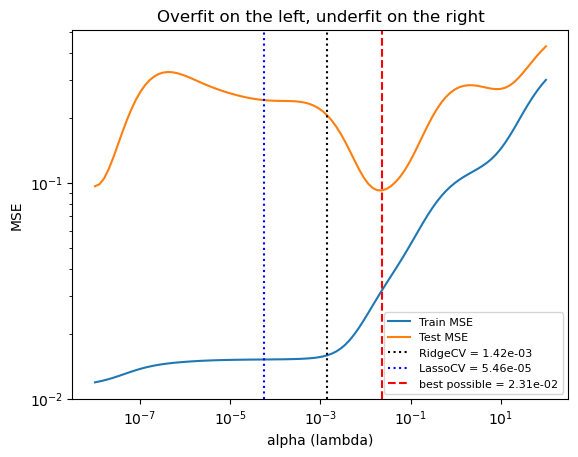

RidgeCV                    test MSE      0.2052 | max|beta|         5.58
LassoCV                    test MSE      0.1974 | max|beta|         7.74


In [18]:
#### Pick alpha ####

alphas = np.logspace(-8, 2, 100)
tr_curve, te_curve = [], []
for a in alphas:
    m = poly_model(Ridge(alpha=a)).fit(X_train, y_train)
    tr_curve.append(mean_squared_error(y_train, m.predict(X_train)))
    te_curve.append(mean_squared_error(y_test, m.predict(X_test)))

## Ridge L2
ridge_cv = poly_model(RidgeCV(alphas=alphas)).fit(X_train, y_train)
best_alpha_l2 = ridge_cv[-1].alpha_

## Lasso L1
lasso_cv = poly_model(LassoCV(alphas=alphas, cv=5, max_iter=100000)).fit(X_train, y_train)
best_alpha_l1 = lasso_cv[-1].alpha_

## Plot comparison
plt.loglog(alphas, tr_curve, label="Train MSE")
plt.loglog(alphas, te_curve, label="Test MSE")
plt.axvline(best_alpha_l2, color="k", ls=":", label=f"RidgeCV = {best_alpha_l2:.2e}")         # best alpha from RidgeCV based on very limited training data
plt.axvline(best_alpha_l1, color="b", ls=":", label=f"LassoCV = {best_alpha_l1:.2e}")         # best alpha from LassoCV based on very limited training data
plt.axvline(alphas[int(np.argmin(te_curve))], color="r", ls="--",
            label=f"best possible = {alphas[int(np.argmin(te_curve))]:.2e}")              # best possible alpha according to testing result
plt.xlabel("alpha (lambda)"); plt.ylabel("MSE"); plt.legend(fontsize=8)
plt.title("Overfit on the left, underfit on the right"); plt.show()

report("RidgeCV", ridge_cv.predict(X_grid), ridge_cv.predict(X_test), ridge_cv[-1].coef_)
report("LassoCV", lasso_cv.predict(X_grid), lasso_cv.predict(X_test), lasso_cv[-1].coef_)

### Data augmentation

This demonstration tries to fix the overfitting by increasing the number of data with copies. 

We simply add a small Gaussian noise on the existing training datasets.

training points: 20 -> 200
OLS (no augmentation)      test MSE      1.1365 | max|beta|      3.7e+03
OLS + augmentation         test MSE      0.0831 | max|beta|     1.65e+03


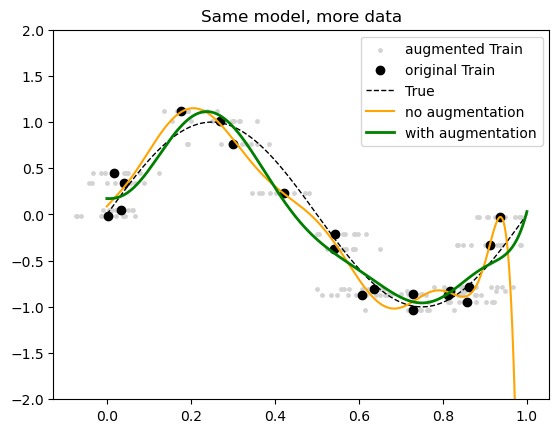

In [19]:
def augmentation(Xa, ya, n_copies=10, sigma=0.05, seed=None):
    rng = np.random.default_rng(seed)
    Xa_rep = np.repeat(Xa, n_copies, axis=0)
    ya_rep = np.repeat(ya, n_copies)
    return Xa_rep + rng.normal(0, sigma, Xa_rep.shape), ya_rep

X_a, y_a = augmentation(X_train, y_train)
print(f"training points: {len(y_train)} -> {len(y_a)}")

ols_aug = poly_model(LinearRegression()).fit(X_a, y_a)

report("OLS (no augmentation)", ols.predict(X_grid), ols.predict(X_test), ols[-1].coef_)
report("OLS + augmentation", ols_aug.predict(X_grid), ols_aug.predict(X_test), ols_aug[-1].coef_)

plt.scatter(X_a, y_a, s=6, c="lightgrey", label="augmented Train")
plt.scatter(X_train, y_train, c="k", label="original Train")
plt.plot(X_grid, true_f(X_grid.ravel()), "k--", lw=1, label="True")
plt.plot(X_grid, ols.predict(X_grid), "orange", label="no augmentation")
plt.plot(X_grid, ols_aug.predict(X_grid), "g", lw=2, label="with augmentation")
plt.ylim(-2, 2)
plt.legend()
plt.title("Same model, more data")
plt.show()

### Comparison between remedies

In [20]:
rows = [
    ("OLS (baseline)", ols.predict(X_grid), ols.predict(X_test)),
    ("Ridge (CV alpha)",         ridge_cv.predict(X_grid), ridge_cv.predict(X_test)),
    ("Lasso (CV alpha)",         lasso_cv.predict(X_grid), lasso_cv.predict(X_test)),
    ("Data augmentation",        ols_aug.predict(X_grid), ols_aug.predict(X_test)),
]

print(f"{'method':<28}{'test MSE':>12}")
print("-" * 40)
for name, pg, pt in rows:
    mse = mean_squared_error(y_test, pt)
    print(f"{name:<28}{mse:12.4f}")
print(f"{'(True Function)':<28}{0.0:12.4f}")


method                          test MSE
----------------------------------------
OLS (baseline)                    1.1365
Ridge (CV alpha)                  0.2052
Lasso (CV alpha)                  0.1974
Data augmentation                 0.0831
(True Function)                   0.0000


## Data Imbalance

Another thing that is particularly important but tends to be overlooked in regression problems is ***data imbalance***. It is routinely emphasised in classification tasks, yet rarely discussed for regression. Real-world populations are not uniformly distributed, and model fitting is prone to being biased towards the dominant population ([Guo et al. 2024](https://arxiv.org/abs/2411.10915); [Yu et al. 2023](https://arxiv.org/abs/2306.15895)).

Imbalance in regression can be seen from input and output perspectives: 

- Feature diversity: **input space**; poor predictions for underrepresented inputs, but input space can be high-dimensional, resulting in difficulty to balance every dimensions.
- Target diversity: **output space**; rare target values (tails) are underestimated, i.e. [regression to the mean](https://en.wikipedia.org/wiki/Regression_toward_the_mean). 

### Feature Diversity
This reflects a straightforward problem: a model cannot predict well for inputs it rarely or never sees. The training domain therefore matters for every model. However, resolving this issue is challenging because balance must be achieved in a high-dimensional feature space, where density estimates and neighbourhoods become unreliable. 

#### Example
Many works train models with spectroscopic redshifts as the target labels to predict photometric redshifts from multi-band galaxy images. However, spectroscopic samples are dominated by bright galaxies due to the sensitivity. Two galaxies can have the same redshift but very different colours and brightness. 

#### Potential Solutions
1. **Data-level solutions**: increase the datasets by acquiring labels where the coverage is missing.

2. **Project features to a different space in which to measure balance**: balancing on all raw features is rarely feasible, so one could conduct dimensional reduction to project the feature space to a lower-dimensional space, e.g. PCA, autoencoder embeddings, self-organising maps

3. **Weighting solutions**: there are some weighting techniques, such as density-ratio weighting and inverse-density weighting, which provide different weights based on the density in the feature space.  

4. **Model-level solutions**: domain adaption, physics-informed models

### Target Diversity
This is usually what people try to address in regression problem. The target itself is often skewed or long-tailed: most samples sit close to the average (or high density region), while extreme values are rare. When optimising a model with MSE, or similar loss functions, the training result is biased towards common values. 

#### Example
For example, the metallicity distribution of observed stars is strongly skewed. Most stars in the solar neighbourhood and Galactic disk have roughly solar metallicity, around \[Fe/H\] $\approx 0$. Very metal-poor stars, below about −2, are rare, and extremely metal-poor stars (below −3) are rarer. If one wish to build a model to predict metallicity of stars and use the predicted values to select interesting extremely metal-poor stars, this imbalance would prevent them from developing a working model for stars with such low metallicity range. 

#### Potential Solutions
1. **Random Sampling**: downsample the dense region or upsample the sparse region

2. **Target transformation**: transform the target distribution by mapping it to a relatively uniform distribuiton for training, e.g. logarithm.

3. **Weighting solutions**: e.g. inverse-density weighting

4. **Multi-stage models**

# Session 3 - Non-linear Regressors

## Neural Networks

### Quick recap

As this week has mentioned, neural networks are actually **a combination of many linear regression models**. Note that to be consistent with the common notation way in machine learning, we change the notation in this session. 

Given input features $\mathbf{x} \in \mathbb{R}^d$, linear regression predicts

$$
\hat{y} = \mathbf{w}^\top \mathbf{x} + b = w_1 x_1 + w_2 x_2 + \dots + w_d x_d + b
$$

For a dataset of $n$ examples stacked in a matrix $X \in \mathbb{R}^{n \times d}$:

$$
\hat{\mathbf{y}} = X\mathbf{w} + b
$$

A linear regression model is equivalent to a neural network with only one layer with one output, without any activation function.

<div align="center">
    <img src="nn_linear.png" width="400">
</div>

To increase the complexity, we stack multiple linear models by introducing middle layers in a neural network. 

<div align="center">
    <img src="nn_stack.png" width="450">
</div>

The number of parameters in this model is $(md + m + m + 1) = m(d+2)+1$. This is however still a linear regression model. The non-linearity is then introduced by the activation functions: 

$$
\mathbf{h} = \sigma(W_1 \mathbf{x} + \mathbf{b}_1)
$$

- linear: $\sigma(z)=z$
- ReLu: $\max(0, z)$

The activation function of the output layer depends on the range of the target value; in many cases, it does not need an activation function (default: linear). 

### Loss function

Then, as what you have learned on Tuesday, we choose a loss function and carry out backpropagation to update the parameters:
$$
\theta \leftarrow \theta - \eta \frac{\partial L}{\partial \theta}, \qquad \theta \in \{W_1, \mathbf{b}_1, \mathbf{w}_2, b_2\}
$$

For regression task, common choices of loss functions are:

- **Mean Squared Error (MSE)**: $(\hat{y} - y)^2$. This assumes Gaussian shape, and easy impacted by outliers.
- **Mean Absolute Error (MAE)**: $\lvert \hat{y} - y \rvert$. Reaction to outliers is better than MSE as it counts only linearly.
- **Huber**: $\frac{1}{2}(\hat{y} - y)^2$ if $\lvert \hat{y} - y \rvert \le \delta$; otherwise $\delta\left(\lvert \hat{y} - y \rvert - \frac{1}{2}\delta\right)$. Good behaviour towards outliers $-$ with MSE's smoothness near 0 and MAE's robustness for large errors.

### Regularisation

To prevent overfitting, one can implement **regularisation**, i.e. L1, L2. As mentioned earlier, we add a penalty term: $L(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + \lambda \cdot \text{Penalty}(\boldsymbol{\theta}).$

With Ridge (L2) for example, $L_{\text{ridge}} = \frac{1}{n}\sum_i(\hat{y}_i - y_i)^2 + \lambda\|\mathbf{w}\|^2$:

$$
L_{\text{NN}} = \frac{1}{n}\sum_i(\hat{y}_i - y_i)^2 + \lambda\left(\|W_1\|^2 + \|\mathbf{w}_2\|^2\right)
$$

### Other controls on model complexity

- Number of hidden units: similar to polynomial degree and number of input features, this controls the number of parameters inside a NN.
- Early stopping (stop when validation loss rises)
- Dropout: randomly deactivates a fraction of neurons
- Hyperparameter tuning/ Cross-validation

> **Bias–variance tradeoff** is exactly the same concept as in linear regression; neural networks just let us move much further toward the low-bias end.


### Summary Comparison

| Aspect | Linear regression | Neural network regression |
|---|---|---|
| Model | $\mathbf{w}^\top\mathbf{x} + b$ | $\mathbf{w}_2^\top \sigma(W_1\mathbf{x} + \mathbf{b}_1) + b_2$ or more if deeper|
| Features | Raw inputs (or hand-crafted) | Learned hidden representations |
| Functions it can represent | Hyperplanes | Arbitrary continuous functions (given enough units) |
| Loss | commonly MSE, but depending on cases | -- |
| Probabilistic justification | Gaussian noise MLE | -- |
| Loss surface | Convex | Non-convex, usually much more complex shape |
| Interpretability | High (coefficients have meaning) | Low |
| Data needed | Small datasets OK | Usually more data |


## Hyperparameter Tuning for NN

The performance of a neural network quite strongly depends on the hyperparameters. Unlike linear regression where you may have a good solution in one step (the analytical solution) and only a single dial to tune (e.g. $\lambda$ in Ridge/Lasso), a neural network has many dials that interact with each other, and each "trial" requires a full training run on a non-convex loss surface.

These "dials" are called `hyperparameters`, which controls the shape of the loss function. 

### Parameters versus hyperparameters
- **Parameters** $\theta = \{W_1, \mathbf{b}_1, \mathbf{w}_2, b_2, \dots\}$: learned from the data by gradient descent.
- **Hyperparameters**: chosen *before* training; they define the model and how it is trained. They cannot be learned by gradient descent because the training loss alone would always prefer the most flexible model.

| Category | Hyperparameter | What it controls | Typical search range |
|---|---|---|---|
| Architecture | number of hidden layers | depth (complexity) | 1 – 4 |
| | number of units per layer | width (complexity) | 16 – 512, often powers of 2 |
| | activation function | type of non-linearity | ReLU, ELU, tanh |
| Regularisation | L2 strength $\lambda$ | penalty on large weights | $10^{-6}$ – $10^{-2}$ (log scale) |
| | dropout rate | fraction of neurons switched off | 0 – 0.5 |
| | early-stopping patience | how long to wait before stopping | 5 – 20 epochs |
| Optimisation | learning rate $\eta$ | step size in $\theta \leftarrow \theta - \eta \nabla_\theta L$ | $10^{-4}$ – $10^{-1}$ (log scale) |
| | batch size | noise in each gradient estimate | 16 – 256 |
| | optimiser | update rule | Adam, SGD with momentum |

### Search strategies

- **Manual search**: change one thing at a time and watch the learning curves. Good for building intuition.
- **Grid search**: try every combination of a pre-defined list of values. Cost grows exponentially: 5 values for 6 hyperparameters is $5^6 = 15{,}625$ training runs.
- **Random search**: sample combinations at random from ranges. With the same budget, random search tries many more distinct values of each hyperparameter, which matters because usually only a few hyperparameters are really important ([Bergstra & Bengio, 2012](https://jmlr.org/papers/v13/bergstra12a.html)).
- **Bayesian optimisation** (e.g. [KerasTuner](https://keras.io/keras_tuner/)): uses the results of previous trials to decide where to sample next. More efficient when each training run is expensive.

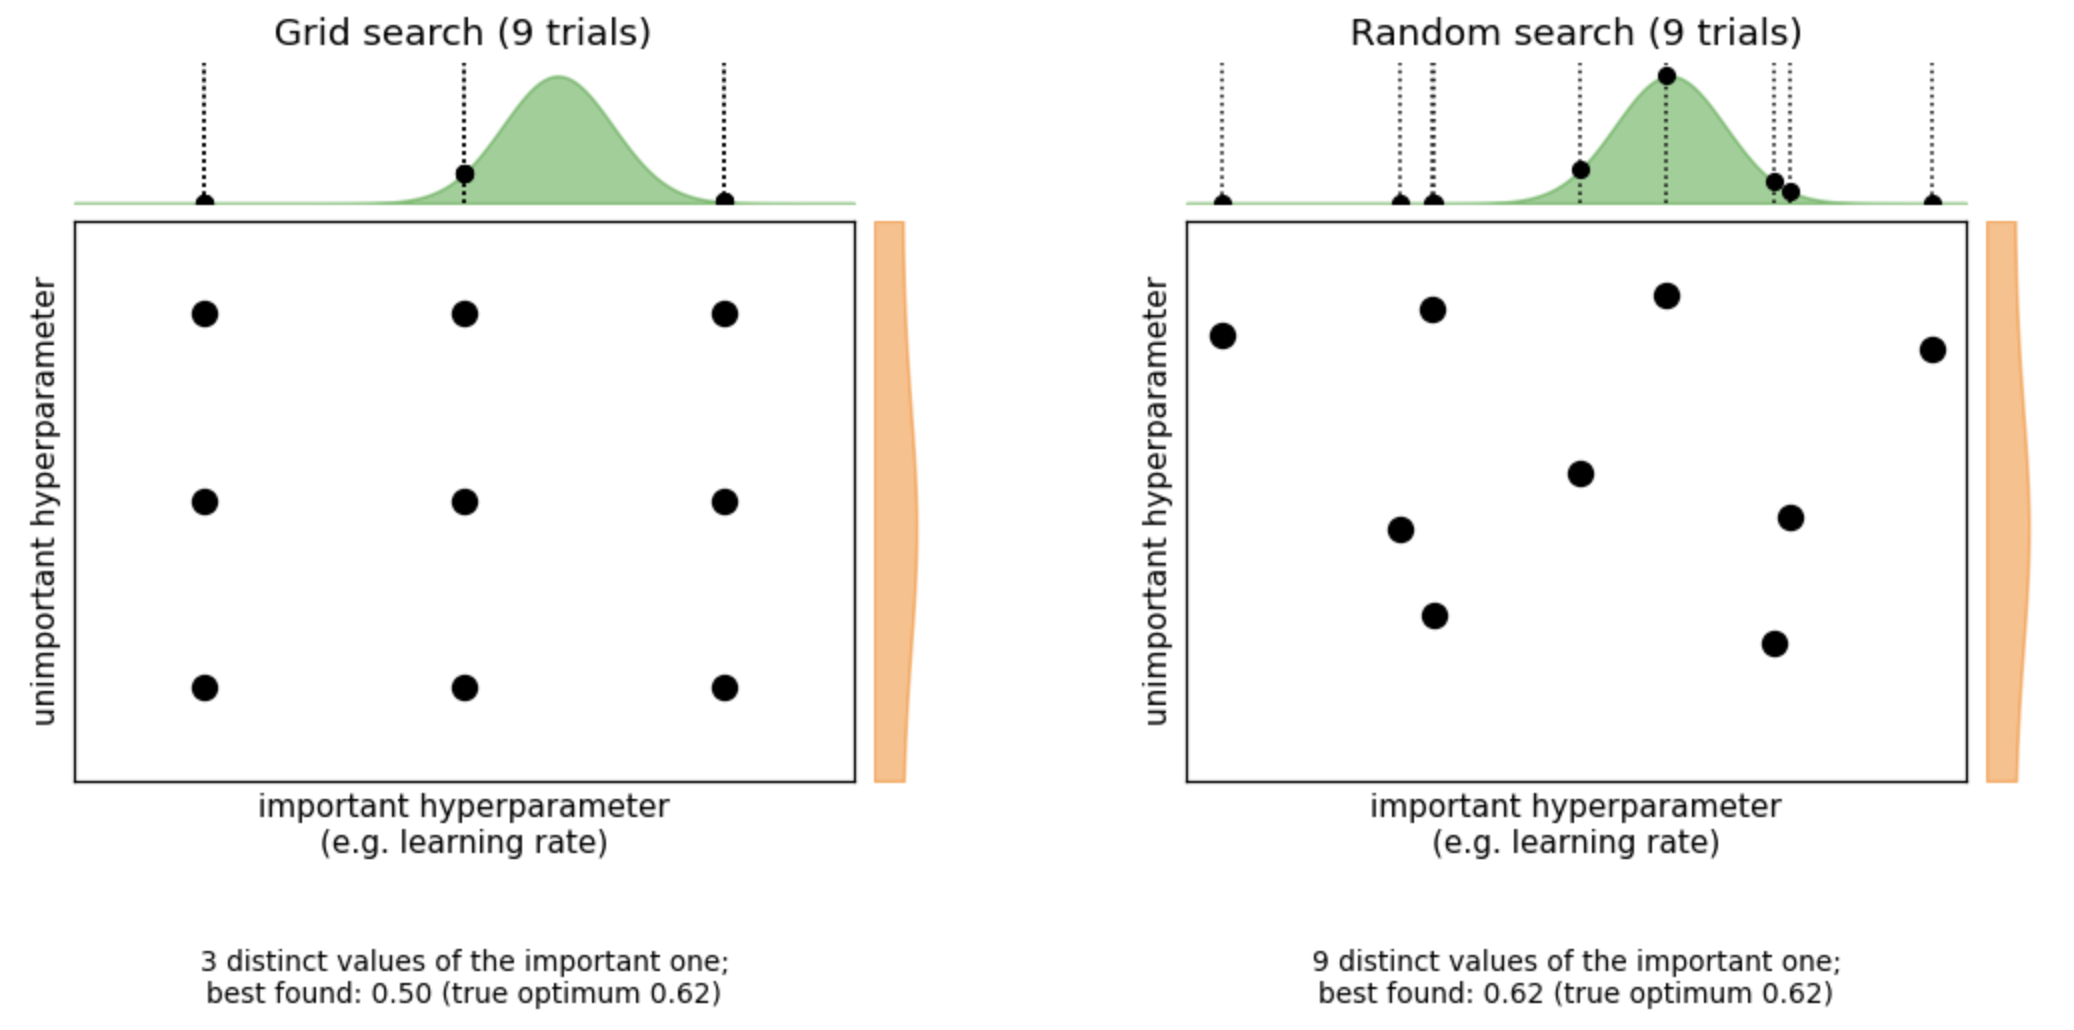


### Bayesian Optimisaion

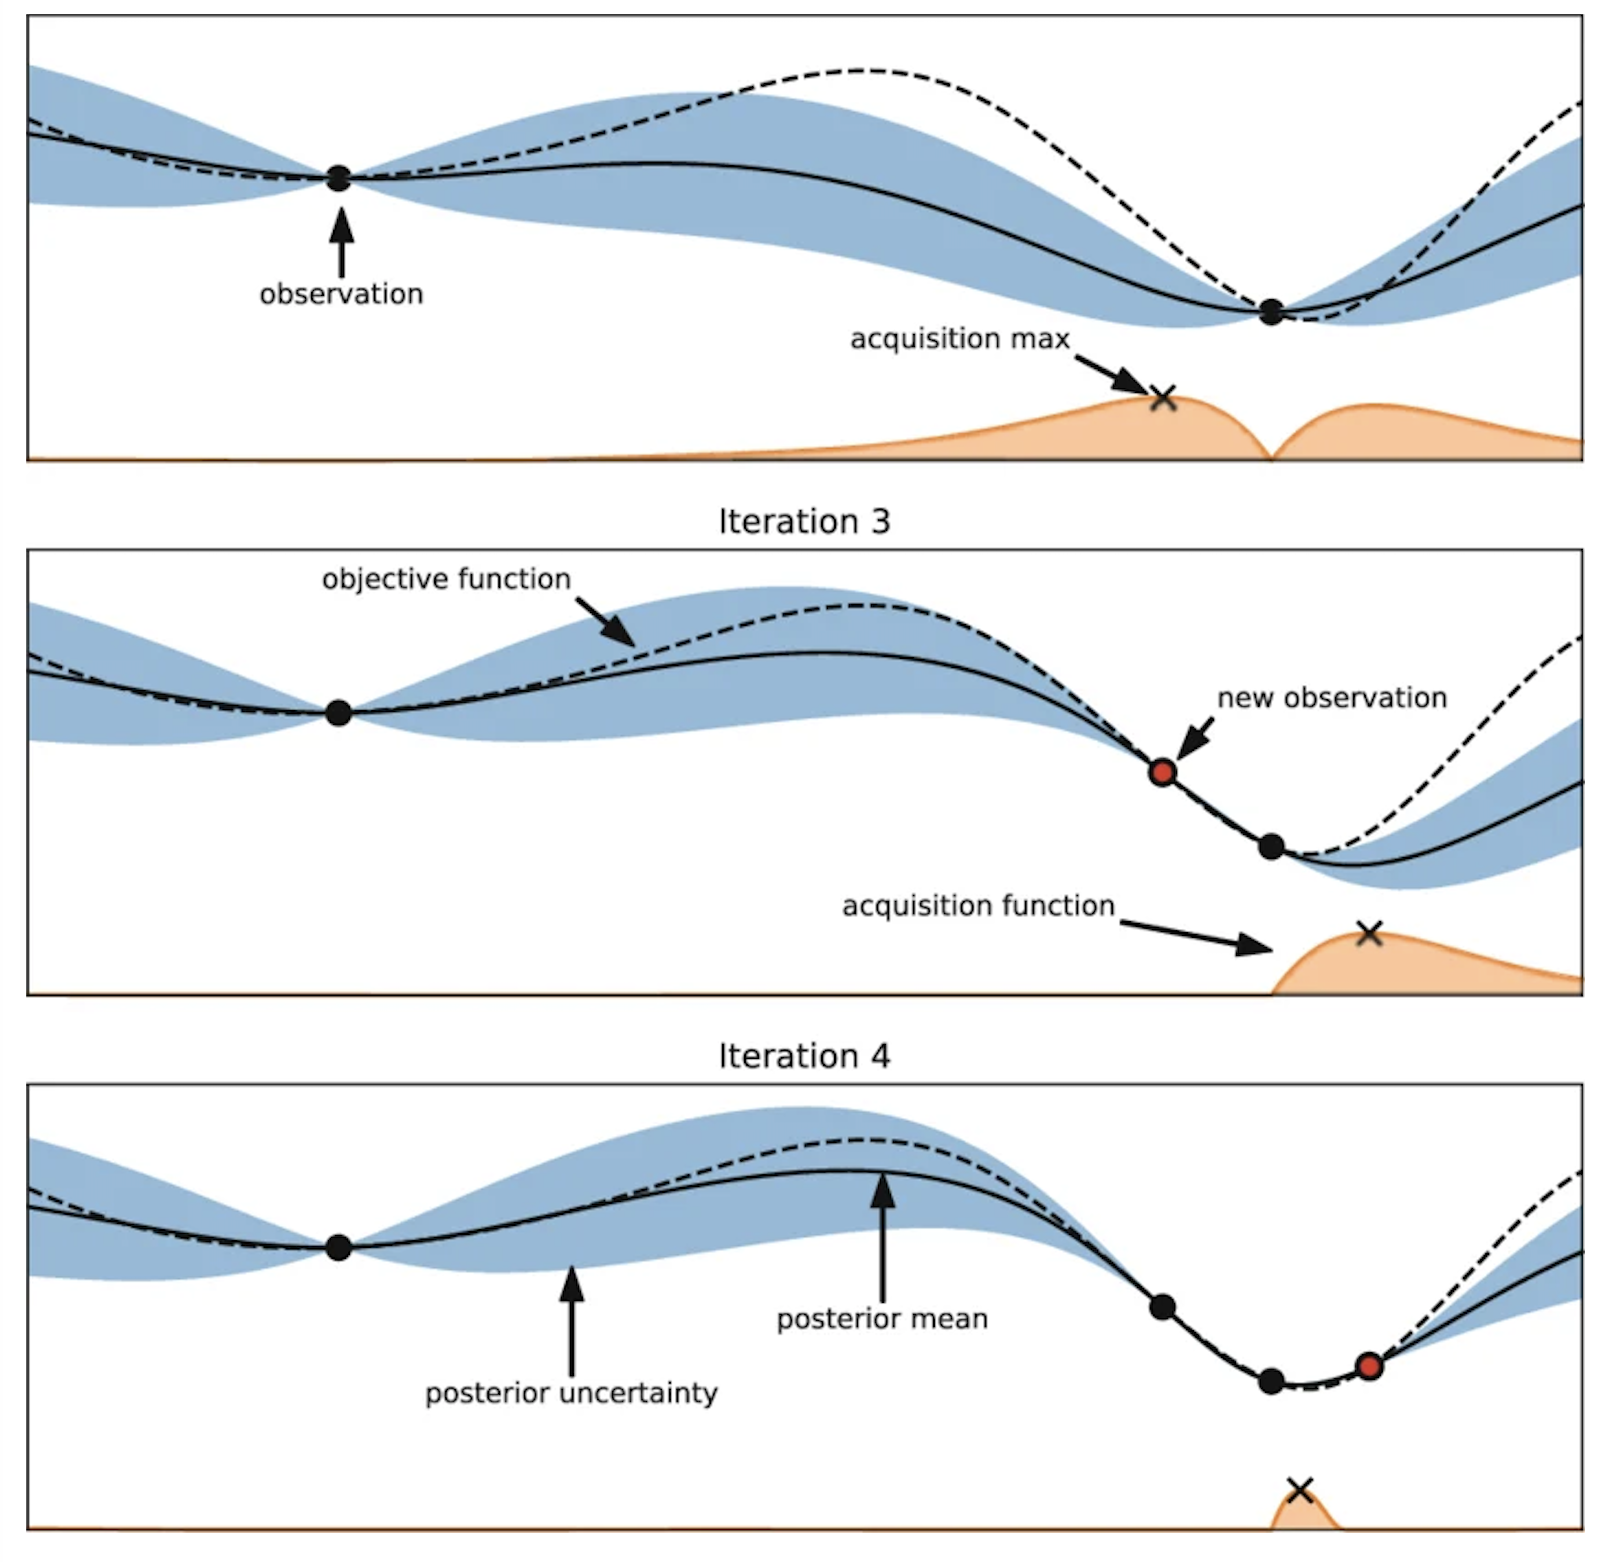

## Tree-based Regressor

### Quick recap

Tree-based algorithm is fundamentally different from linear regression. A tree-based regressor makes no assumption that the target follows a (linear) relationship. Instead, it recursively partitions the feature space into smaller regions (leaves) using threshold-based decisions.

<div align="center">
    <img src="tree_scheme.png" width="600">
</div>

Given a set of samples $\Omega = \{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$, where $\mathbf{x}_i = (x_{i1}, x_{i2}, \dots, x_{ip})^\top \in \mathbb{R}^p$ denotes a set of $p$ input features of the $i$-th sample and $y_i \in \mathbb{R}$ denotes its corresponding target value. At each node (turning point), the tree selects a feature $x_j$ and a threshold $t$ to divide the samples into two subsets; the region then splits into two child regions (leaves). 

At a node containing observations $S$, for each feature $j$ and threshold $t$, define two child regions:

$$
L(j,t) = \{ i \in S : x_{ij} \le t \}, \qquad R(j,t) = \{ i \in S : x_{ij} > t \}
$$

Within each region (leaf), $R_m$, we calculate a constant representing the value of the region (leaf):

$$
\hat{c}_m = \frac{1}{|R_m|} \sum_{x_i \in R_m} y_i,
$$

where $|R_m|$ is the *count* of training points in that leaf. Thus, this shows taking an average $-$ adding up the targets of the training points in the leaf, divide by how many there are. 

The model of a tree can be described as followed:

$$
\hat{f}(x) = \sum_{m=1}^{M} c_m \, \mathbb{1}(x \in R_m)
$$

The prediction at $x$ is the sum, over all $M$ leaves, of that leaf's constant times an indicator of whether $x$ falls in that leaf, determined by whether it equals to 1 or not. This does the action of **"find the leaf $x$ lands in and return its constant."**

### To regression

The key difference between classifcation and regression tasks are on the loss function. For regression task, here uses sum of squared errors instead of MSE to keep the size of leaves (not to take average) and report total error: 

$$
\min_{j,\,t} \big[\text{SSE}(L) + \text{SSE}(R)\big] = \min_{j,\,t} \left[ \sum_{i \in L} (y_i - \bar{y}_L)^2 + \sum_{i \in R} (y_i - \bar{y}_R)^2 \right]
$$

Equivalently, maximise the **reduction in SSE** (sometimes called variance reduction):

$$
\Delta = \text{SSE}(S) - \big[\text{SSE}(L) + \text{SSE}(R)\big]
$$

> **Bias–variance tradeoff**: a shallow tree is therefore a high bias model. 

## Hands-on: non-linear regressors

In the following exercises, we will try to use images' pixels as the input features to increase the dimension in feature space. Since we are not doing CNN, we will simply flatten the 2D images (with 3 bands) into one-dimensional array. 

The non-linear regressor, we can have more discussion on high dimensional space. 

In [21]:
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error as MAE
from PIL import Image

In [22]:
#### Read data and construct initial datasets ####

image_dir = 'known_datasets_imgs/'
filenames = np.array([fn[:-4] for fn in os.listdir(image_dir) if fn.endswith('.jpg')])

newsize = 16

#X = np.zeros((len(filenames), newsize, newsize, 3))              # Use this if you want to build CNN model
X = np.zeros((len(filenames), int(newsize * newsize * 3)))        # Use this for scikit-learn and NN models (keras)
Y = np.zeros((len(filenames)))

for ix, fn in enumerate(filenames):
    file_path = os.path.join(image_dir, fn + '.jpg')
    with Image.open(file_path) as img:
        img = img.convert('RGB').resize((newsize, newsize), Image.Resampling.LANCZOS) 
        ## Flatten to one-dimensional input ##
        X[ix] = np.array(img.resize((newsize, newsize))).flatten()
        ## For CNN input ## 
        #img = img.resize((newsize, newsize))
        #for ik in range(3):
        #    X[ix,:,:,ik] = np.array(img)[:,:,ik]
    Y[ix] = np.float64(fn[19:])

print(X.shape, Y.shape)

(2000, 768) (2000,)


In [23]:
#### Spilt training and testing data (80:20) ####

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1600, 768) (400, 768) (1600,) (400,)


### Recap using linear regression models

For comparison purpose, let's try linear regression models first. 

mae: 0.3876    mse: 0.2588   rmse: 0.5088   r2: 0.3770
number of beta: 768
max beta: 0.03954849994197699    min beta: 1.3077002223403113e-05
number of non-zero beta: 757


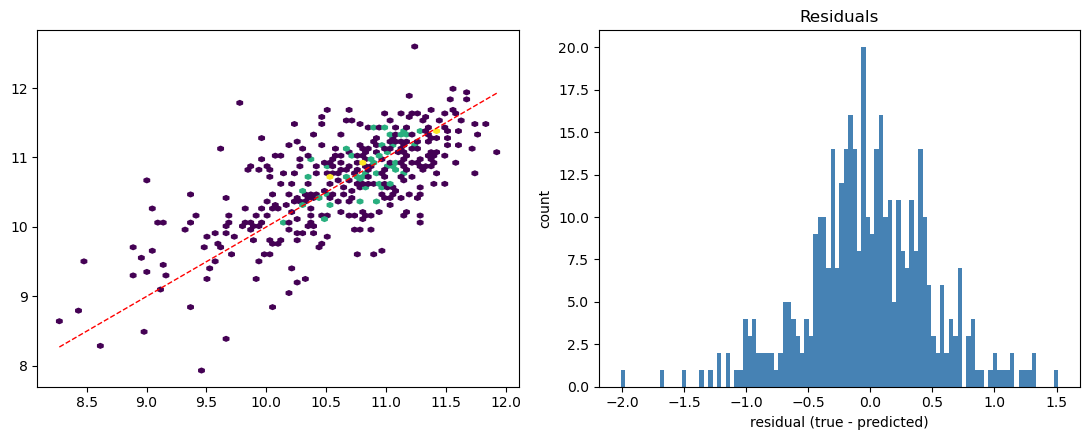

In [24]:
def fit(X, y):
    reg = sklearn.linear_model.LinearRegression()
    return reg.fit(X, y)

linear_reg = fit(X_train, y_train)                  # Use scikit-learn package
beta = linear_reg.coef_
y_pred = linear_reg.predict(X_test)

mae = MAE(y_test, y_pred)
mse, rmse, r2 = evaluate(y_test, y_pred)            # Evaluation
print(f"mae: {mae:.4f}    mse: {mse:.4f}   rmse: {rmse:.4f}   r2: {r2:.4f}")
result_plot(y_test, y_pred)

coef = "[" + ", ".join(f"{c:.4f}" for c in beta) + "]" 
print(f"number of beta: {len(beta)}")
print(f"max beta: {np.abs(beta).max()}    min beta: {np.abs(beta).min()}" )
print(f"number of non-zero beta: {len(beta[np.abs(beta) > 1e-4])}")
#print(f"beta: {coef}")

### Tree-based regression

Check the following websites and choose a tree-based algorithm for this task. If you have no preference, one can try the most basic one: `DecisionTreeRegressor`. 
- [sklearn.tree](https://scikit-learn.org/stable/api/sklearn.tree.html)
- [sklearn.ensemble](https://scikit-learn.org/stable/api/sklearn.ensemble.html)

mae: 0.3577    mse: 0.2389   rmse: 0.4888   r2: 0.4250


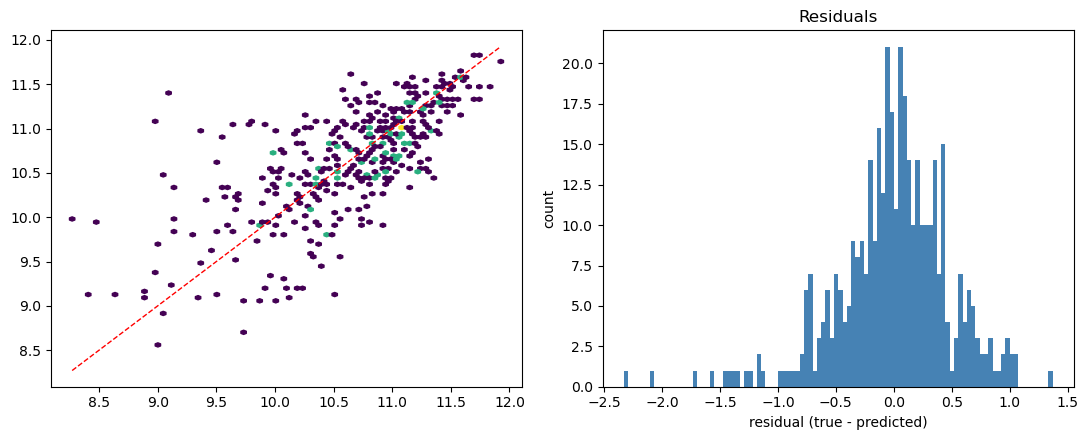

In [25]:
#### Decision Tree Regressor ####

from sklearn.tree import DecisionTreeRegressor

reg = DecisionTreeRegressor()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

mae = MAE(y_test, y_pred)
mse, rmse, r2 = evaluate(y_test, y_pred)            # Evaluation
print(f"mae: {mae:.4f}    mse: {mse:.4f}   rmse: {rmse:.4f}   r2: {r2:.4f}")
result_plot(y_test, y_pred)

### Neural Networks

Check out the notebook from Wednesday's lecture to build and optimise your NN models for this task. An architecture template is provided based on the notebook of Wednesday's lecture. 

```python
def create_nn_model(input_shape=(128*128*3)):
    """
    Create a NN model for regression task.
    
    Args:
        input_shape: flatten images -> (height * width * channels)
    
    Returns:
        Compiled Keras model
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        # Fully Connected Layers
        layers.Dense(4, activation='relu', name='dense1'),
        # Output Layer
        layers.Dense(1, activation='linear', name='output')
    ])

    return model
```

In [26]:
## for NN building ##
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam

def create_nn_model(input_shape=(newsize*newsize*3,)):
    """
    Create a NN model for regression task.
    
    Args:
        input_shape: flatten images -> (height * width * channels)
    
    Returns:
        Compiled Keras model
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        # Fully Connected Layers
        layers.Dense(4, activation='relu', name='dense1'),
        # Output Layer
        layers.Dense(1, activation='linear', name='output')
    ])

    return model

# Create the model
model = create_nn_model()

# Compile the model
model.compile(
    optimizer=Adam(),
    loss='mse',
)

# Display model summary
model.summary()

## NN model fit ##
model.fit(X_train, y_train, epochs=100, verbose=0, batch_size=32,
          callbacks=[
                        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
                    ])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ (None, 4)              │         3,076 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,081 (12.04 KB)

 Trainable params: 3,081 (12.04 KB)

 Non-trainable params: 0 (0.00 B)

/opt/anaconda3/lib/python3.13/site-packages/keras/src/callbacks/early_stopping.py:100: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step
mae: 1.0138    mse: 1.6785   rmse: 1.2956   r2: -3.0401


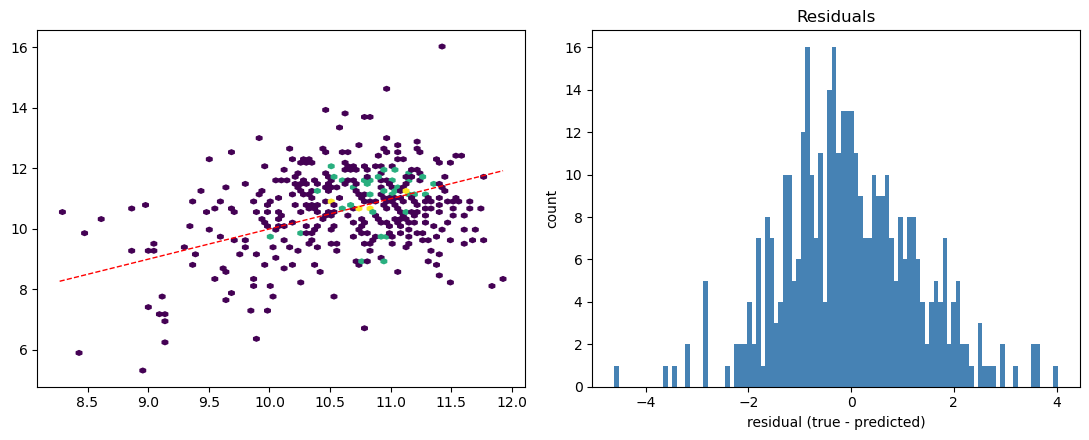

In [27]:


## Evaluation ##
y_pred = model.predict(X_test)
y_pred = y_pred.reshape(-1)


mae = MAE(y_test, y_pred)
mse, rmse, r2 = evaluate(y_test, y_pred)            # Evaluation
print(f"mae: {mae:.4f}    mse: {mse:.4f}   rmse: {rmse:.4f}   r2: {r2:.4f}")
result_plot(y_test, y_pred)

#### Increase complexity

Now, let's increase some complexity of the models by **add more layers and more neurons**. What do you observe?

In [28]:
def create_nn_model(input_shape=(newsize*newsize*3,)):
    """
    Create a NN model for regression task.
    
    Args:
        input_shape: flatten images -> (height * width * channels)
    
    Returns:
        Compiled Keras model
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        # Fully Connected Layers
        layers.Dense(64, activation='relu', name='dense1'),
        layers.Dense(32, activation='relu', name='dense2'),
        layers.Dense(16, activation='relu', name='dense3'),
        # Output Layer
        layers.Dense(1, activation='linear', name='output')
    ])

    return model

# Create the model
model = create_nn_model()

# Compile the model
model.compile(
    optimizer=Adam(),
    loss='mse',
)

# Display model summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ (None, 64)             │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,841 (202.50 KB)

 Trainable params: 51,841 (202.50 KB)

 Non-trainable params: 0 (0.00 B)

/opt/anaconda3/lib/python3.13/site-packages/keras/src/callbacks/early_stopping.py:100: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
mae: 1.0026    mse: 1.9480   rmse: 1.3957   r2: -3.6888


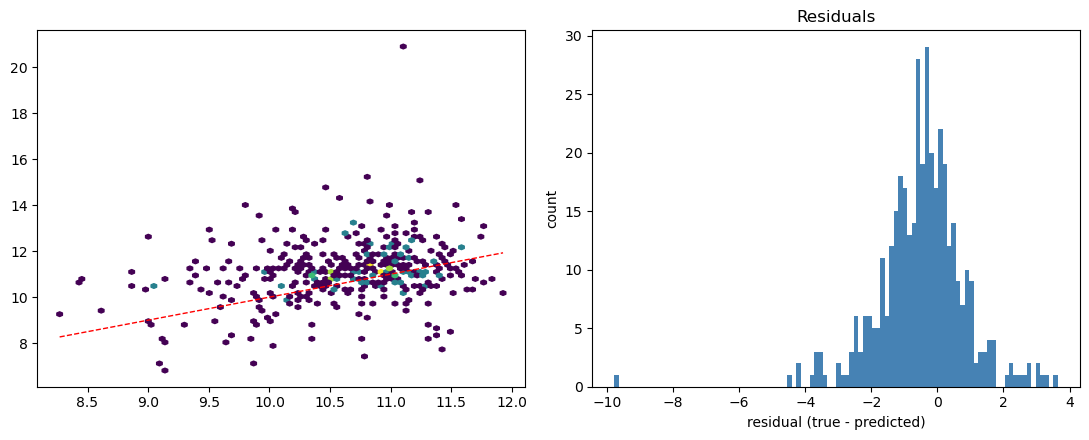

In [29]:
## NN model fit ##
model.fit(X_train, y_train, epochs=100, verbose=0, batch_size=32,
          callbacks=[
                        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
                    ])

## Evaluation ##
y_pred = model.predict(X_test)
y_pred = y_pred.reshape(-1)

mae = MAE(y_test, y_pred)
mse, rmse, r2 = evaluate(y_test, y_pred)            # Evaluation
print(f"mae: {mae:.4f}    mse: {mse:.4f}   rmse: {rmse:.4f}   r2: {r2:.4f}")
result_plot(y_test, y_pred)

#### Add other controls on model complexity

- Add BatchNormalisation: `layers.BatchNormalization()`
- Add regularisation, e.g. L1 and L2: layers.Dense(32, ``kernel_regularizer=regularizers.l2(0.01)``)
- Add dropout layers: ``layers.Dropout(0.3)``
- Add EarlyStopping: when doing `model.fit` -> add `keras.callbacks.EarlyStopping(monitor="val_loss", patience=5)` 

In [30]:
def create_nn_model(input_shape=(newsize*newsize*3,)):
    """
    Create a NN model for regression task.
    
    Args:
        input_shape: flatten images -> (height * width * channels)
    
    Returns:
        Compiled Keras model
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        # Fully Connected Layers
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='dense1'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='dense2'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.01), name='dense3'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        # Output Layer
        layers.Dense(1, activation='linear', name='output')
    ])

    return model

# Create the model
model = create_nn_model()

# Compile the model
model.compile(
    optimizer=Adam(),
    loss='mse',
)

# Display model summary
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ (None, 32)             │        24,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,505 (99.63 KB)

 Trainable params: 25,393 (99.19 KB)

 Non-trainable params: 112 (448.00 B)

In [31]:
## NN model fit ##
model.fit(X_train, y_train, epochs=100, verbose=0, batch_size=32,
          callbacks=[
                        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
                    ])

/opt/anaconda3/lib/python3.13/site-packages/keras/src/callbacks/early_stopping.py:100: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
mae: 0.4963    mse: 0.3387   rmse: 0.5820   r2: 0.1848


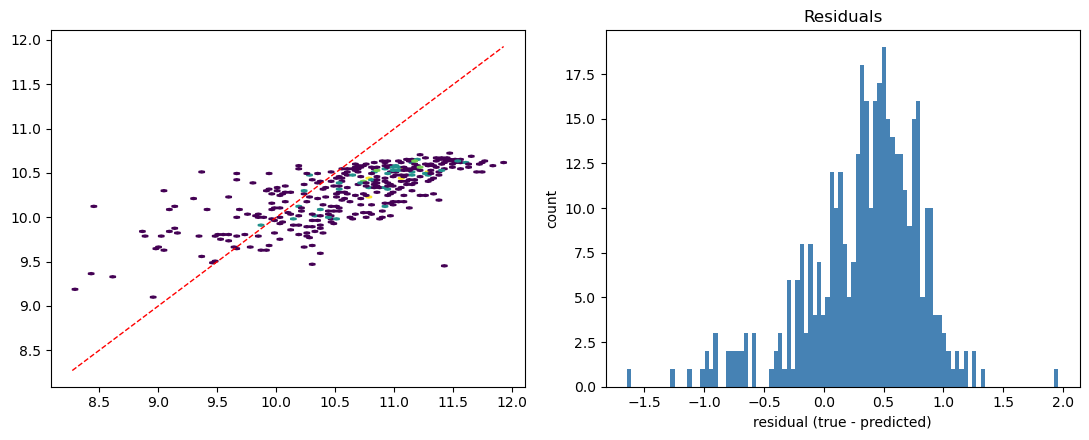

In [32]:
## Evaluation ##
y_pred = model.predict(X_test)
y_pred = y_pred.reshape(-1)

mae = MAE(y_test, y_pred)
mse, rmse, r2 = evaluate(y_test, y_pred)            # Evaluation
print(f"mae: {mae:.4f}    mse: {mse:.4f}   rmse: {rmse:.4f}   r2: {r2:.4f}")
result_plot(y_test, y_pred)

### Hyperparameter Tuning for the NN

Install Keras Tuner by the following commands, if you do not have them. 
``` 
pip install tensorboard
pip install keras-tuner --upgrade
```
In this exercise, we will use [Keras Tuner (Bayesian Optimisation)](https://keras.io/keras_tuner/) to search for optimal hyperparameters setup for this task. In particular, we will try 
- random search
- Bayesian optimisation

First, we split a **validation set** from the training data, and rewrite `create_nn_model()` so that every hyperparameter becomes an argument.

We will tune the following hyperparameters: 
- number of layers
- number of neurons
- dropout rate
- l2

In [33]:
## Create a validation set out of the training data. The test set stays untouched until the very end. ##
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=0)
print(f"train: {X_tr.shape}   validation: {X_val.shape}   test (held out): {X_test.shape}")

train: (1440, 768)   validation: (160, 768)   test (held out): (400, 768)


In [34]:
#### Helpers: Hyperparameter tuning ####

def build_nn(n_layers=2, n_units=32, activation='relu', dropout=0.1, l2=0.0, lr=1e-3,
             input_shape=(newsize*newsize*3,)):
    """Same architecture as create_nn_model(), but every hyperparameter is now an argument."""
    if l2 > 0:
        reg = regularizers.l2(l2)
    else: 
        None
    model = models.Sequential([layers.Input(shape=input_shape)])
    for i in range(n_layers):
        units = max(n_units // (2 ** i), 4)              # halve the width at each layer: e.g. 32 -> 16
        model.add(layers.Dense(units, activation='relu', kernel_regularizer=reg))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='relu'))       # output layer: no activation for regression
    model.compile(optimizer=Adam(), loss='mse')
    return model

def train_and_score(params, epochs=100, patience=10, seed=0):
    """Train one configuration on (X_tr, y_tr); score it on (X_val, y_val)."""
    keras.utils.set_random_seed(seed)                     # same initial weights for a fair comparison
    arch = {k: v for k, v in params.items() if k != 'batch_size'}
    model = build_nn(**arch)
    hist = model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                     epochs=epochs, batch_size=params.get('batch_size', 32), verbose=0,
                     callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)])
    y_val_pred = model.predict(X_val, verbose=0).reshape(-1)
    val_mse, _, _ = evaluate(y_val, y_val_pred)           # MSE without the L2 penalty term
    return val_mse, model, hist

In [35]:
#### KerasTuner set-up ####

import keras_tuner as kt

objective = kt.Objective('val_loss', direction='min')      # setup validation on MSE

## Training settings shared by every trial ## 
search_kwargs = dict(
    x=X_tr, y=y_tr,
    validation_data=(X_val, y_val),                        # tune on the validation set, never the test set
    epochs=100, batch_size=32, verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
)

#### Define search space

Complete `build_hp(hp)` function below, so that it returns `build_nn(...)` with every hyperparameter drawn from `hp`. Using the following ranges, or play different values yourself. 

| Hyperparameter | Range | Hint |
|---|---|---|
| `n_layers` | 1 – 3 | integer: `hp.Int` |
| `n_units` | 16, 32, 64, 128 | list of options: `hp.Choice` |
| `dropout` | 0.0, 0.1, 0.3, 0.5 | `hp.Choice` |
| `l2` | $10^{-6}$ – $10^{-2}$ | acts on a scale: `hp.Float(..., sampling='log')` |

In [36]:
#### Define search space ####

def build_hp(hp):
    return build_nn(
        n_layers   = hp.Int('n_layers', 1, 3),
        n_units    = hp.Choice('n_units', [8, 16, 32, 64, 128]),
        dropout    = hp.Choice('dropout', [0.0, 0.1, 0.3, 0.5]),
        l2         = hp.Float('l2', 1e-3, 1e-2, sampling='log'),
    )

build_hp(kt.HyperParameters()).summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │         6,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,193 (24.19 KB)

 Trainable params: 6,177 (24.13 KB)

 Non-trainable params: 16 (64.00 B)

#### Random search

In [37]:
random_tuner = kt.RandomSearch(
    hypermodel        = build_hp, 
    objective         = objective, 
    max_trials        = 20,
    seed=0, directory='kt_tuning', project_name='random', overwrite=True,
)
random_tuner.search(**search_kwargs)
random_tuner.results_summary(num_trials=3)

Results summary
Results in kt_tuning/random
Showing 3 best trials
Objective(name="val_loss", direction="min")

Trial 10 summary
Hyperparameters:
n_layers: 1
n_units: 16
dropout: 0.0
l2: 0.00813098819964959
Score: 0.22431591153144836

Trial 06 summary
Hyperparameters:
n_layers: 1
n_units: 64
dropout: 0.5
l2: 0.0025321882721518582
Score: 0.2925606071949005

Trial 08 summary
Hyperparameters:
n_layers: 2
n_units: 16
dropout: 0.1
l2: 0.0027665114937009427
Score: 0.350158154964447


In [38]:
best_random = random_tuner.get_best_hyperparameters(1)[0]
print("Best configuration (Random Search):", best_random.values)

Best configuration (Random Search): {'n_layers': 1, 'n_units': 16, 'dropout': 0.0, 'l2': 0.00813098819964959}


Best configuration: {'n_layers': 1, 'n_units': 16, 'dropout': 0.0, 'l2': 0.00813098819964959}
Baseline NN   mae: 0.4963    mse: 0.3387   rmse: 0.5820   r2: 0.1848
Tuned NN      mae: 0.4963    mse: 0.1941   rmse: 0.4405   r2: 0.5329


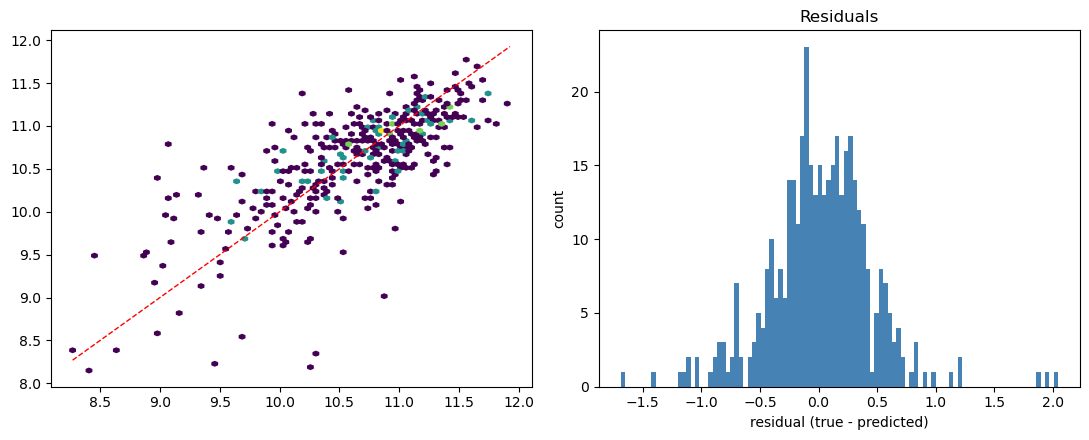

In [39]:
best = best_random.values
best = {k: (v.item() if hasattr(v, 'item') else v) for k, v in best.items()} 
print("Best configuration:", best)

## Final model ##
_, tuned_model, _ = train_and_score(best)
y_pred_base  = model.predict(X_test, verbose=0).reshape(-1)          # untuned model from above
y_pred_tuned = tuned_model.predict(X_test, verbose=0).reshape(-1)

for name, yp in [('Baseline NN', y_pred_base), ('Tuned NN', y_pred_tuned)]:
    mae = MAE(y_test, y_pred)
    mse, rmse, r2 = evaluate(y_test, yp)
    print(f"{name:12s}  mae: {mae:.4f}    mse: {mse:.4f}   rmse: {rmse:.4f}   r2: {r2:.4f}")

result_plot(y_test, y_pred_tuned)

#### Bayesian Optimisation

In [40]:
bayes_tuner = kt.BayesianOptimization(
    hypermodel         = build_hp,
    objective          = objective,
    max_trials         = 20,
    seed=0, directory='kt_tuning', project_name='bayes', overwrite=True,
)

bayes_tuner.search(**search_kwargs)
bayes_tuner.results_summary(num_trials=3)

Results summary
Results in kt_tuning/bayes
Showing 3 best trials
Objective(name="val_loss", direction="min")

Trial 10 summary
Hyperparameters:
n_layers: 1
n_units: 8
dropout: 0.1
l2: 0.0015528776288402323
Score: 0.20622101426124573

Trial 16 summary
Hyperparameters:
n_layers: 1
n_units: 32
dropout: 0.1
l2: 0.005727689564763438
Score: 0.2474871575832367

Trial 01 summary
Hyperparameters:
n_layers: 1
n_units: 16
dropout: 0.0
l2: 0.0015439988990669689
Score: 0.27287718653678894


In [41]:
best_bayes = bayes_tuner.get_best_hyperparameters(1)[0]
print("Best configuration (Baye Search):", best_bayes.values)

Best configuration (Baye Search): {'n_layers': 1, 'n_units': 8, 'dropout': 0.1, 'l2': 0.0015528776288402323}


Best configuration: {'n_layers': 1, 'n_units': 8, 'dropout': 0.1, 'l2': 0.0015528776288402323}
Baseline NN   mae: 0.4963    mse: 0.3387   rmse: 0.5820   r2: 0.1848
Tuned NN      mae: 0.4963    mse: 0.1988   rmse: 0.4458   r2: 0.5216


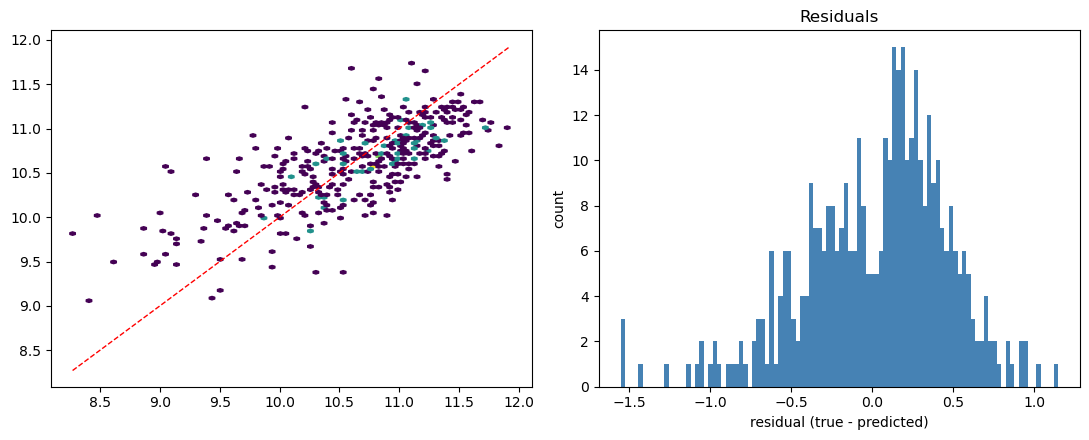

In [42]:
best = best_bayes.values
best = {k: (v.item() if hasattr(v, 'item') else v) for k, v in best.items()}   # numpy -> python types
print("Best configuration:", best)

## Final model ##
_, tuned_model, _ = train_and_score(best)
y_pred_base  = model.predict(X_test, verbose=0).reshape(-1)          # untuned model from above
y_pred_tuned = tuned_model.predict(X_test, verbose=0).reshape(-1)

for name, yp in [('Baseline NN', y_pred_base), ('Tuned NN', y_pred_tuned)]:
    mae = MAE(y_test, y_pred)
    mse, rmse, r2 = evaluate(y_test, yp)
    print(f"{name:12s}  mae: {mae:.4f}    mse: {mse:.4f}   rmse: {rmse:.4f}   r2: {r2:.4f}")

result_plot(y_test, y_pred_tuned)

### Predict new datasets: images

The folder `new_datasets_imgs/` contains 5 galaxy images without stellar mass measurement. Build a non-linear regression model of your own choice, and record your answer for each galaxy on this [**Google Doc**](https://docs.google.com/document/d/1Wcu2wqmJlopgx4V42Fe1ZqupgcFVDA0xlR90FwoM_q4/edit?usp=sharing) (Session 3).

In [45]:
#### Read data ####

image_dir = 'new_datasets_imgs/'
filenames = np.array([fn[:-4] for fn in os.listdir(image_dir) if fn.endswith('.jpg')])

newsize = 16   # Original image size were probably too big and the overfitting problem would be too serious. 

#X = np.zeros((len(filenames), newsize, newsize, 3))              # Use this if you want to build CNN model
X = np.zeros((len(filenames), int(newsize * newsize * 3)))        # Use this for scikit-learn and NN models (keras)

for ix, fn in enumerate(filenames):
    file_path = os.path.join(image_dir, fn + '.jpg')
    with Image.open(file_path) as img:
        img = img.convert('RGB').resize((newsize, newsize), Image.Resampling.LANCZOS) 
        ## Flatten to one-dimensional input ##
        X[ix] = np.array(img.resize((newsize, newsize))).flatten()
        ## For CNN input ## 
        #img = img.resize((newsize, newsize))
        #for ik in range(3):
        #    X[ix,:,:,ik] = np.array(img)[:,:,ik]

print(X.shape)

(5, 768)


In [48]:
y_new = tuned_model.predict(X, verbose=0).reshape(-1)
print(y_new)

[ 8.9696455  9.493236  10.246339  10.543223  10.459984 ]


In [54]:
#### Prediction from participants ####

preds4new = {'answers': [10.42, 9.315, 11.007, 8.967, 8.768], 
             'Sunny': [8.9696455,  9.493236,  10.246339,  10.543223,  10.459984 ], 
             'Zuzanna' : [8.944854,  9.84479,  10.330264, 10.597072, 10.511046],
             'Daniel': [8.782284, 10.47654 ,  9.653119, 10.235993, 10.350731],
             'Yfke': [10.913,  9.919, 8.244,  9.740, 10.470], 
             #'Rasmus' : [-2.6998262, -1.4945042, -2.659813,  -5.073003,  -2.4134147],
             'Will': [10.6505375, 10.6505375, 10.6505375, 10.6505375, 10.6505375],
             'Will2':[10.064631, 10.396276, 10.502186, 8.875829, 9.552437]

            }

=== Per-galaxy distribution ===
            true    mean  median    std    min     max    sem  mean - true
Galaxy 0  10.420   9.721   9.517  0.944  8.782  10.913  0.385       -0.699
Galaxy 1   9.315  10.130  10.158  0.446  9.493  10.651  0.182        0.815
Galaxy 2  11.007   9.938  10.288  0.897  8.244  10.651  0.366       -1.069
Galaxy 3   8.967  10.107  10.390  0.692  8.876  10.651  0.282        1.140
Galaxy 4   8.768  10.332  10.465  0.394  9.552  10.651  0.161        1.564 

=== Crowd average ===
RMSE of crowd mean  : 1.099 dex
Mean bias (pred-true): +0.350 dex

=== Leaderboard (ranked by RMSE) ===
         rank   RMSE    MAE   bias  max_abs_err
Will2       1  0.659  0.563  0.183        1.081
Sunny       2  1.270  1.131  0.247        1.692
Will        3  1.292  1.098  0.955        1.883
Zuzanna     4  1.312  1.211  0.350        1.743
Daniel      5  1.413  1.401  0.204        1.638
Yfke        6  1.532  1.267  0.162        2.763 

🥇 Will2: RMSE = 0.659 dex, MAE = 0.563 dex
🥈 Sunny: 

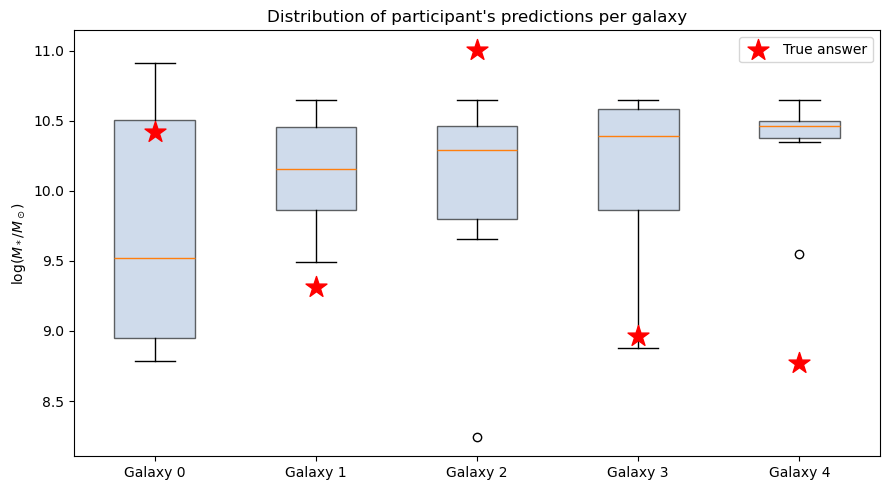

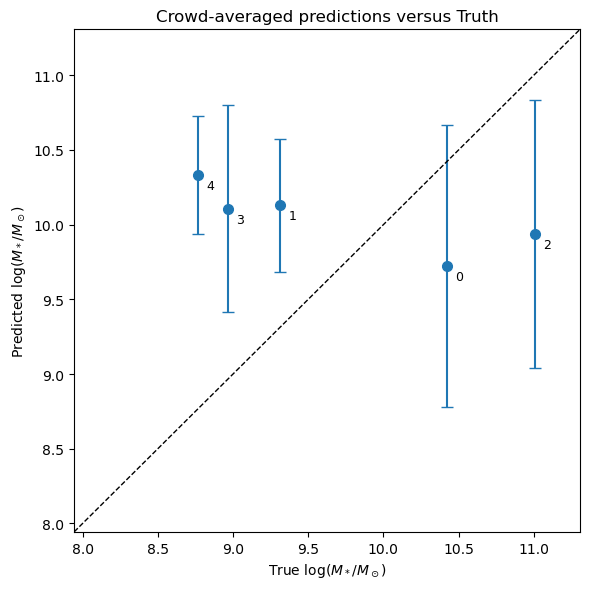

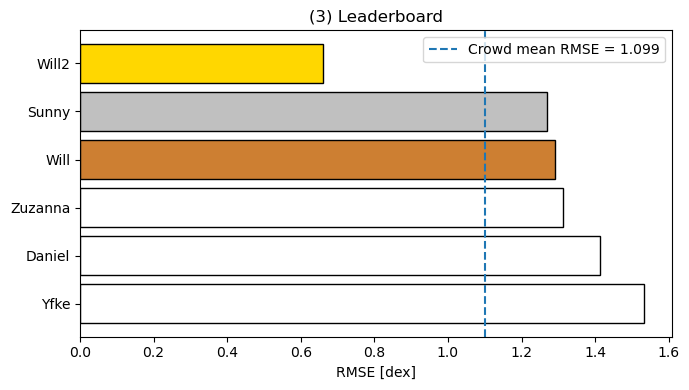

In [55]:
#### Evaluation and Leaderboard ####

df = pd.DataFrame(preds4new)
df.index = [f'Galaxy {i}' for i in range(len(df))]

truth = df.pop('answers')
participants = df.columns.tolist()
galaxies = df.index.tolist()
x = np.arange(len(galaxies))

######################################### 
# 1. Prediction distribution per galaxy #
#########################################
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([df.loc[g].values for g in galaxies], positions=x, widths=0.5,
           patch_artist=True, boxprops=dict(facecolor='lightsteelblue', alpha=0.6))

ax.scatter(x, truth.values, marker='*', s=250, color='red', zorder=4, label='True answer')
ax.set_xticks(x)
ax.set_xticklabels(galaxies)
ax.set_ylabel(r'$\log(M_*/M_\odot)$')
ax.set_title('Distribution of participant\'s predictions per galaxy')
ax.legend()
plt.tight_layout()

print('=== Per-galaxy distribution ===')
summary = pd.DataFrame({
    'true': truth,
    'mean': df.mean(axis=1),
    'median': df.median(axis=1),
    'std': df.std(axis=1, ddof=1),
    'min': df.min(axis=1),
    'max': df.max(axis=1),
})
summary['sem'] = summary['std'] / np.sqrt(len(participants))
summary['mean - true'] = summary['mean'] - summary['true']
print(summary.round(3), '\n')


########################################
# 2. Pred versus True: One-to-one plot #
########################################
fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(truth, summary['mean'], yerr=summary['std'], fmt='o', color='C0',
            ecolor='C0', capsize=4, ms=7)
lo = min(truth.min(), df.values.min()) - 0.3
hi = max(truth.max(), df.values.max()) + 0.3
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
for g, t, m in zip(galaxies, truth, summary['mean']):
    ax.annotate(g.split()[-1], (t, m), xytext=(6, -10), textcoords='offset points', fontsize=9)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel(r'True $\log(M_*/M_\odot)$')
ax.set_ylabel(r'Predicted $\log(M_*/M_\odot)$')
ax.set_title('Crowd-averaged predictions versus Truth')
plt.tight_layout()

crowd_rmse = np.sqrt(np.mean((summary['mean'] - truth) ** 2))
print('=== Crowd average ===')
print(f'RMSE of crowd mean  : {crowd_rmse:.3f} dex')
print(f'Mean bias (pred-true): {summary["mean - true"].mean():+.3f} dex\n')


##################
# 3. Leaderboard #
##################
resid = df.sub(truth, axis=0)
scores = pd.DataFrame({
    'RMSE': np.sqrt((resid ** 2).mean()),
    'MAE': resid.abs().mean(),
    'bias': resid.mean(),
    'max_abs_err': resid.abs().max(),
}).sort_values(['RMSE', 'MAE'])                           # rank by RMSE, MAE breaks ties
scores.insert(0, 'rank', range(1, len(scores) + 1))

print('=== Leaderboard (ranked by RMSE) ===')
print(scores.round(3), '\n')
medals = ['🥇', '🥈', '🥉']
for medal, (name, row) in zip(medals, scores.head(3).iterrows()):
    print(f'{medal} {name}: RMSE = {row.RMSE:.3f} dex, MAE = {row.MAE:.3f} dex')

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['gold', 'silver', '#cd7f32'] + ['white'] * (len(scores) - 3)
ax.barh(scores.index[::-1], scores['RMSE'][::-1], color=colors[::-1], edgecolor='k')
ax.axvline(crowd_rmse, color='C0', ls='--', label=f'Crowd mean RMSE = {crowd_rmse:.3f}')
ax.set_xlabel('RMSE [dex]')
ax.set_title('(3) Leaderboard')
ax.legend()
plt.tight_layout()